# AI-Powered Intrusion Detection System with Real-Time Threat Detection
### Information Security — CLO 4 · Assignment 1

| | |
|---|---|
| **Student** | Muhammad Nafay Aftab |
| **Enrolment** | 03-134222-087 |
| **Class** | BSCS-8A |
| **Instructor** | Dr. Nadeem Sarwar |
| **Repository** | https://github.com/Nafay-Aftab/CLO4-IDS-ML-Solution |

> **This notebook is self-contained.** Every function it runs is defined in the cells below; it does not import
> the project's `src/` package (which powers the SOC dashboard and command-line scripts). The final cell verifies
> that this notebook reproduces the saved project results in `artifacts/` exactly.

---
## 1. Executive Summary & CISO Mandate

**Scenario.** SecureNet Corp.'s CISO has asked for a proof-of-concept machine-learning layer to augment the
existing signature-based NIDS: classify every network flow as *Normal* or *Malicious*, fast enough for inline use,
and explain *why* an alert fired.

**Solution.** A leak-free scikit-learn pipeline (One-Hot + log1p + RobustScaler) feeding a tuned
**Random Forest** champion, benchmarked against a Decision-Tree baseline on
**UNSW-NB15** (257,673 labelled flows, 9 modern attack families). The decision threshold τ* is calibrated on
out-of-bag validation probabilities; the 20 % test fold is touched once.

**Headline (untouched test fold, τ* = 0.50).** Accuracy **94.71%**, attack recall
**94.60%**, precision **97.05%**, F1 **95.81%**, false-alarm rate
**5.09%**, ROC-AUC **0.9915**. The contract's ≥ 95 % gate on accuracy/recall/F1 with FPR < 5 %
is **not fully met**: F1 clears 95 %, while accuracy and recall land ~0.3–0.4 pp short. Section 7 presents the
evidence that the gap is data-driven — neither an alternative tree ensemble nor engineered features lift recall
above ≈ 94.3 % under a 5 % FPR budget — and the result is reported as measured, not tuned against the test set.

**Real-time.** Batched inference runs at **6.4 µs/flow ≈ 157,418 flows/s** on a
laptop CPU — comfortably line-rate for NetFlow/IPFIX-style flow export. (Figure from the dedicated benchmark run in
`artifacts/realtime_report.json`; Section 12 re-measures live, and wall-clock timings vary by a few µs between runs.)

## 2. Library Imports, Configuration & Seed Initialisation

In [1]:
import json, time, warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")  # figures are rendered to PNG and displayed inline below
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter
from scipy.stats import skew
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score, precision_score,
                             recall_score, roc_auc_score)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, StratifiedShuffleSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, RobustScaler
from sklearn.tree import DecisionTreeClassifier
from IPython.display import Image, display

warnings.filterwarnings("ignore", category=UserWarning)

# ---- paths (run from the repo root or from notebooks/) ----
ROOT = Path.cwd() if (Path.cwd() / "dataset").exists() else Path.cwd().parent
DATA_DIR, ARTIFACT_DIR = ROOT / "dataset", ROOT / "artifacts"
TRAIN_CSV = DATA_DIR / "UNSW_NB15_training-set.csv"
TEST_CSV = DATA_DIR / "UNSW_NB15_testing-set.csv"
FIG_DIR = ROOT / "notebooks" / "outputs"   # notebook-local figure files (images are also embedded below)
FIG_DIR.mkdir(exist_ok=True)
FIG_DPI = 150

# ---- frozen experimental constants ----
SEED = 42


TARGET = "label"


TARGET_CAT = "attack_cat"


ID_COL = "id"


CATEGORICAL = ["proto", "service", "state"]


LOG1P_FEATURES = ["sbytes", "dbytes", "sload", "dload", "dur", "sinpkt", "dinpkt", "sjit", "djit"]


TEST_SIZE = 0.20

np.random.seed(SEED)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
T_START = time.perf_counter()
print(f"numpy {np.__version__} | pandas {pd.__version__} | scikit-learn {sklearn.__version__} | SEED={SEED}")

numpy 1.26.4 | pandas 2.2.3 | scikit-learn 1.5.2 | SEED=42


*Implementation — figure style (colour-blind-validated palette, hairline chrome, PNG export)*

In [2]:
NORMAL = "#2a78d6"


ATTACK = "#eb6834"


ACCENT = "#1baf7a"


SURFACE = "#fcfcfb"


INK = "#0b0b0b"


INK_2 = "#52514e"


MUTED = "#898781"


GRID = "#e1e0d9"


AXIS = "#c3c2b7"


CRITICAL = "#d03b3b"


DIVERGING = LinearSegmentedColormap.from_list("blue_gray_red", ["#184f95", "#2a78d6", "#f0efec", "#e34948", "#a12d2d"])


SEQUENTIAL = LinearSegmentedColormap.from_list("blue_seq", ["#f0efec", "#9ec5f4", "#3987e5", "#1c5cab", "#0d366b"])


def apply_style() -> None:
    plt.rcParams.update({
        "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
        "font.family": ["Segoe UI", "DejaVu Sans"], "font.size": 10,
        "axes.edgecolor": AXIS, "axes.linewidth": 0.8, "axes.labelcolor": INK_2,
        "axes.titlecolor": INK, "axes.titlesize": 12, "axes.titleweight": "semibold",
        "axes.titlelocation": "left", "axes.titlepad": 10,
        "axes.spines.top": False, "axes.spines.right": False,
        "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "grid.linestyle": "-",
        "axes.axisbelow": True,
        "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
        "legend.frameon": False, "legend.labelcolor": INK_2,
        "lines.linewidth": 2, "lines.solid_capstyle": "round",
    })


def save(fig, name: str) -> str:
    path = FIG_DIR / name
    # Respect the figure's own facecolor (rcParams would repaint dark figures with the light surface).
    fig.savefig(path, dpi=FIG_DPI, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.close(fig)
    return str(path)


apply_style()

## 3. Data Ingestion & Sanitisation
Both official UNSW-NB15 partitions are read with `utf-8-sig` (strips the UTF-8 BOM that otherwise corrupts the
first header into `\ufeffid`) and concatenated. The identifier `id` and both targets are separated from the
42-feature matrix.

*Implementation — ingestion, sanitisation, stratified split, integrity report*

In [3]:
def _read(path) -> pd.DataFrame:
    df = pd.read_csv(path, encoding="utf-8-sig", low_memory=False)
    # Defensive: strip any residual BOM / whitespace from headers (e.g. '﻿id').
    df.columns = [c.replace("﻿", "").strip() for c in df.columns]
    return df


def load_raw() -> pd.DataFrame:
    """Concatenate both official UNSW-NB15 partitions into one frame (257,673 rows)."""
    df = pd.concat([_read(TRAIN_CSV), _read(TEST_CSV)], ignore_index=True)
    df[TARGET_CAT] = df[TARGET_CAT].astype(str).str.strip()
    for col in ("proto", "service", "state"):
        df[col] = df[col].astype(str).str.strip()
    return df


def split_xy(df: pd.DataFrame):
    """Separate the identifier and both targets from the 42-feature matrix."""
    X = df.drop(columns=[ID_COL, TARGET, TARGET_CAT])
    return X, df[TARGET].astype(int), df[TARGET_CAT]


def stratified_split(X: pd.DataFrame, y: pd.Series, y_cat: pd.Series):
    """80/20 split stratified on the 10-class attack_cat so rare families (Worms) land in both folds.

    attack_cat is a strict refinement of the binary label, so binary balance is preserved too.
    """
    sss = StratifiedShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=SEED)
    tr, te = next(sss.split(X, y_cat))
    return (X.iloc[tr].reset_index(drop=True), X.iloc[te].reset_index(drop=True),
            y.iloc[tr].reset_index(drop=True), y.iloc[te].reset_index(drop=True),
            y_cat.iloc[tr].reset_index(drop=True), y_cat.iloc[te].reset_index(drop=True))


def load_split():
    """Convenience: raw -> (X_tr, X_te, y_tr, y_te, cat_tr, cat_te)."""
    X, y, y_cat = split_xy(load_raw())
    return stratified_split(X, y, y_cat)


SKEW_FEATURES = ["sbytes", "dbytes", "sload", "dur"]


def integrity_report(df: pd.DataFrame) -> dict:
    raw_train, raw_test = _read(TRAIN_CSV), _read(TEST_CSV)
    num = df.select_dtypes(include=np.number)
    feats = df.drop(columns=["id", TARGET, TARGET_CAT])
    dup_feat = feats.duplicated(keep=False)
    conflict = df[dup_feat].groupby(list(feats.columns), dropna=False)[TARGET].nunique()
    return {
        "rows_training_file": len(raw_train), "rows_testing_file": len(raw_test),
        "rows_total": len(df), "columns_total": df.shape[1],
        "features": feats.shape[1], "categorical_features": len(CATEGORICAL),
        "numerical_features": feats.shape[1] - len(CATEGORICAL),
        "null_cells": int(df.isna().sum().sum()),
        "inf_cells": int(np.isinf(num.to_numpy()).sum()),
        "bom_in_headers": any("﻿" in c for c in df.columns),
        "duplicate_feature_rows": int(feats.duplicated().sum()),
        "duplicate_groups_with_conflicting_labels": int((conflict > 1).sum()),
        "label_counts": df[TARGET].value_counts().sort_index().to_dict(),
        "attack_cat_counts": df[TARGET_CAT].value_counts().to_dict(),
        "n_unique": {c: int(df[c].nunique()) for c in CATEGORICAL},
        "skewness_raw": {c: round(float(skew(df[c])), 2) for c in SKEW_FEATURES},
        "skewness_log1p": {c: round(float(skew(np.log1p(df[c]))), 2) for c in SKEW_FEATURES},
        "orders_of_magnitude": {c: round(float(np.log10(df[c].max() / max(df.loc[df[c] > 0, c].min(), 1e-12))), 1)
                                for c in SKEW_FEATURES},
    }

In [4]:
df = load_raw()
rep = integrity_report(df)
print(f"rows: {rep['rows_training_file']:,} + {rep['rows_testing_file']:,} = {rep['rows_total']:,}  |  columns: {rep['columns_total']}")
print(f"features: {rep['features']} ({rep['categorical_features']} categorical, {rep['numerical_features']} numerical)")
print(f"null cells: {rep['null_cells']}  |  inf cells: {rep['inf_cells']}  |  BOM left in headers: {rep['bom_in_headers']}")
print(f"duplicate feature rows: {rep['duplicate_feature_rows']:,}  |  conflicting-label duplicate groups: {rep['duplicate_groups_with_conflicting_labels']}")
assert rep["rows_total"] == 257_673 and rep["null_cells"] == 0 and rep["inf_cells"] == 0
df.head()

rows: 82,332 + 175,341 = 257,673  |  columns: 45
features: 42 (3 categorical, 39 numerical)
null cells: 0  |  inf cells: 0  |  BOM left in headers: False
duplicate feature rows: 103,989  |  conflicting-label duplicate groups: 414


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.0000,udp,-,INT,2,0,496,0,"90,909.0902",...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.0000,udp,-,INT,2,0,1762,0,"125,000.0003",...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.0000,udp,-,INT,2,0,1068,0,"200,000.0051",...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.0000,udp,-,INT,2,0,900,0,"166,666.6608",...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.0000,udp,-,INT,2,0,2126,0,"100,000.0025",...,1,3,0,0,0,2,3,0,Normal,0


## 4. Security Exploratory Data Analysis
EDA here plays the role of a SOC analyst reviewing SIEM logs before writing detection rules. Each figure below is
the empirical proof for one downstream engineering decision.

*Implementation — the four EDA proofs*

In [5]:
def fig_attack_distribution(df: pd.DataFrame) -> str:
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5.2), gridspec_kw={"width_ratios": [1, 2.2]})
    counts = df[TARGET].value_counts().sort_index()
    bars = a1.bar(["Normal (0)", "Attack (1)"], counts.values, color=[NORMAL, ATTACK], width=0.5)
    for b, v in zip(bars, counts.values):
        a1.text(b.get_x() + b.get_width() / 2, v, f"{v:,}\n{v / len(df):.1%}", ha="center", va="bottom",
                color=INK, fontsize=10)
    a1.set_ylim(0, counts.max() * 1.18)
    a1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x / 1000:.0f}k"))
    a1.set_title("A. Binary label balance")
    a1.set_ylabel("Flows")
    a1.grid(axis="x", visible=False)

    cats = df[TARGET_CAT].value_counts().sort_values()
    colors = [NORMAL if c == "Normal" else ATTACK for c in cats.index]
    a2.barh(cats.index, cats.values, color=colors, height=0.6)
    a2.set_xscale("log")
    a2.set_xlim(50, cats.max() * 6)
    for i, v in enumerate(cats.values):
        a2.text(v * 1.12, i, f"{v:,}  ({v / len(df):.2%})", va="center", color=INK_2, fontsize=9)
    a2.set_title("B. Ten-class traffic composition (log scale)")
    a2.set_xlabel("Flows (log$_{10}$)")
    a2.grid(axis="y", visible=False)
    from matplotlib.patches import Patch
    a2.legend(handles=[Patch(color=NORMAL, label="Normal"), Patch(color=ATTACK, label="Attack family")],
              loc="lower right")
    fig.suptitle("UNSW-NB15 class distribution — 257,673 flows", x=0.01, ha="left", fontsize=14,
                 fontweight="semibold", color=INK)
    fig.text(0.01, -0.02, "Worms / Shellcode / Backdoor are 2–3 orders of magnitude rarer than Generic: "
             "accuracy alone hides their miss rate, so per-family recall is reported in Phase 5.",
             color=MUTED, fontsize=9)
    fig.tight_layout()
    return save(fig, "eda_attack_distribution.png")


def fig_volume_skew(df: pd.DataFrame, rep: dict) -> str:
    sample = df.sample(40_000, random_state=SEED)
    fig, axes = plt.subplots(len(SKEW_FEATURES), 2, figsize=(12, 12))
    for r, feat in enumerate(SKEW_FEATURES):
        for c, (label, tf) in enumerate([("raw", lambda s: s), ("log1p", np.log1p)]):
            ax = axes[r, c]
            for cls, color, name in [(0, NORMAL, "Normal"), (1, ATTACK, "Attack")]:
                vals = tf(sample.loc[sample[TARGET] == cls, feat])
                sns.kdeplot(vals, ax=ax, color=color, fill=True, alpha=0.10, linewidth=2, label=name,
                            cut=0, bw_adjust=0.8, warn_singular=False)
            sk = rep["skewness_raw" if c == 0 else "skewness_log1p"][feat]
            ax.set_title(f"{feat} — {label}   (skewness = {sk:+.2f})", fontsize=11)
            ax.set_xlabel(f"log(1 + {feat})" if c else feat)
            ax.set_ylabel("Density" if c == 0 else "")
            if c == 0:
                ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
            if r == 0 and c == 1:
                ax.legend(loc="upper right")
    fig.suptitle("Heavy-tailed flow volumes: raw vs. log1p-transformed densities", x=0.01, ha="left",
                 fontsize=14, fontweight="semibold", color=INK)
    fig.text(0.01, -0.01, "KDE on a 40,000-flow random sample (seed 42); skewness computed on all 257,673 flows. "
             "Raw mass collapses into a spike at 0 — log1p exposes the separable Normal/Attack modes.",
             color=MUTED, fontsize=9)
    fig.tight_layout()
    return save(fig, "eda_traffic_volume_skew.png")


def fig_top_protocols(df: pd.DataFrame) -> str:
    share = pd.crosstab(df["proto"], df[TARGET], normalize="columns") * 100
    top = df["proto"].value_counts().head(10).index
    share = share.loc[top].iloc[::-1]
    fig, ax = plt.subplots(figsize=(11, 6))
    y = np.arange(len(share))
    h = 0.36
    ax.barh(y + h / 2, share[0], height=h, color=NORMAL, label="Normal traffic")
    ax.barh(y - h / 2, share[1], height=h, color=ATTACK, label="Attack traffic")
    for i, (n, a) in enumerate(zip(share[0], share[1])):
        for val, off in ((n, h / 2), (a, -h / 2)):
            if val >= 0.05:  # label only visible bars; zero-share bars stay unlabelled
                ax.text(val + 0.6, i + off, f"{val:.1f}%", va="center", fontsize=8.5, color=INK_2)
    ax.set_yticks(y, share.index)
    ax.set_xlabel("Share of flows within class (%)")
    ax.set_xlim(0, share.values.max() * 1.12)
    ax.grid(axis="y", visible=False)
    ax.legend(loc="lower right")
    n_proto = df["proto"].nunique()
    tail = 100 - df["proto"].value_counts(normalize=True).head(10).sum() * 100
    ax.set_title(f"Top-10 transport protocols by class  ({n_proto} distinct protocols; "
                 f"remaining {n_proto - 10} carry {tail:.1f}% of flows)")
    ct = pd.crosstab(df["proto"], df[TARGET])
    rare_attack = int((ct[0] == 0).sum())
    fig.text(0.01, -0.02, f"{rare_attack} protocols appear only in attack traffic — a long, sparse tail. "
             "Values unseen in training are mapped to an all-zero vector by OneHotEncoder(handle_unknown='ignore').",
             color=MUTED, fontsize=9)
    fig.tight_layout()
    return save(fig, "eda_top_protocols.png")


def fig_correlation(df: pd.DataFrame) -> str:
    num = df.drop(columns=["id", TARGET_CAT] + CATEGORICAL)
    num = num.loc[:, num.std() > 0]
    corr = num.corr(method="spearman")
    g = sns.clustermap(corr, cmap=DIVERGING, vmin=-1, vmax=1, center=0, figsize=(13, 13),
                       linewidths=0, dendrogram_ratio=0.08, cbar_pos=(0.025, 0.55, 0.018, 0.2),
                       xticklabels=True, yticklabels=True, method="average")
    g.ax_row_dendrogram.set_visible(False)  # column dendrogram already shows the clustering
    g.ax_heatmap.tick_params(labelsize=7.5, colors=INK_2)
    g.ax_heatmap.set_xlabel("")
    g.ax_heatmap.set_ylabel("")
    # Outline the target so its correlated cluster is easy to locate.
    order = [corr.columns[i] for i in g.dendrogram_row.reordered_ind]
    k = order.index(TARGET)
    g.ax_heatmap.add_patch(plt.Rectangle((0, k), len(order), 1, fill=False, edgecolor=INK, lw=1.2))
    g.ax_cbar.set_title("Spearman ρ", fontsize=8, color=INK_2)
    g.figure.suptitle("Clustered Spearman correlation of numerical flow features (label row outlined)",
                      x=0.02, y=1.01, ha="left", fontsize=14, fontweight="semibold", color=INK)
    path = save(g.figure, "eda_feature_correlation.png")
    pairs = corr.where(np.triu(np.ones(corr.shape, bool), 1)).stack()
    return path, pairs.abs().sort_values(ascending=False).head(10).round(3), corr[TARGET].drop(TARGET)

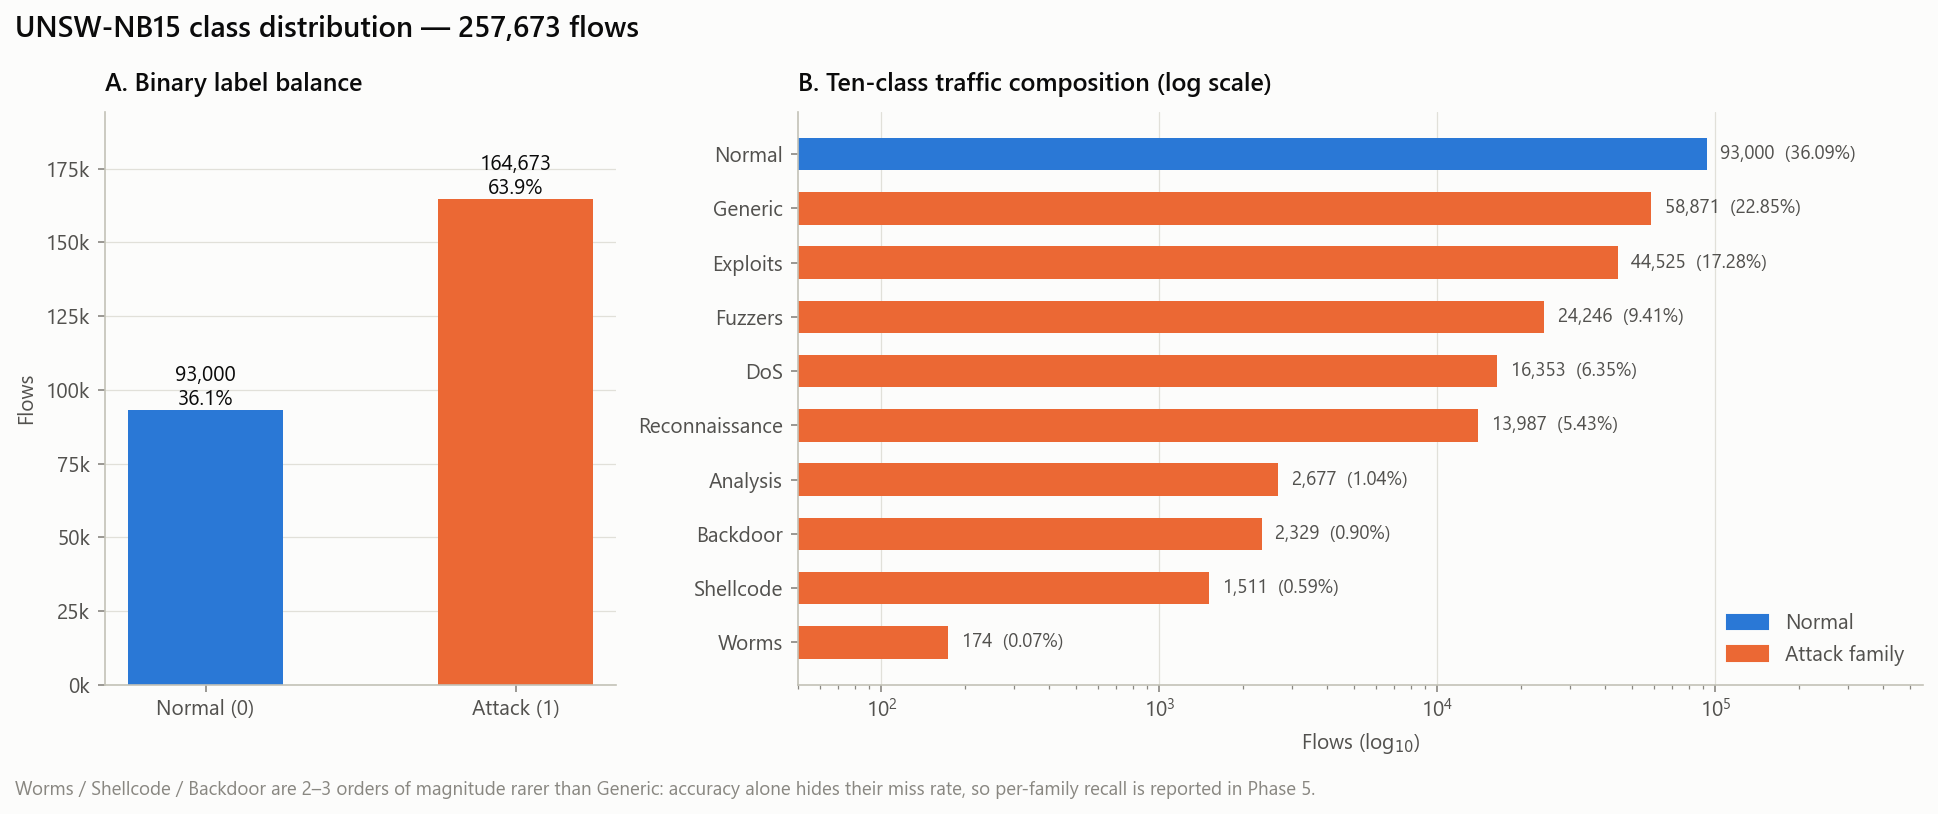

In [6]:
display(Image(filename=fig_attack_distribution(df), width=1000))

**Insight → decision.** Attacks are 63.9 % of flows, but the families span three orders of magnitude
(Generic 58,871 vs Worms 174). Accuracy alone would hide a total failure on Worms, so Section 10 reports recall
per family, and class weighting (`balanced_subsample`) is used instead of SMOTE — interpolating between flow
records fabricates physically impossible packets.

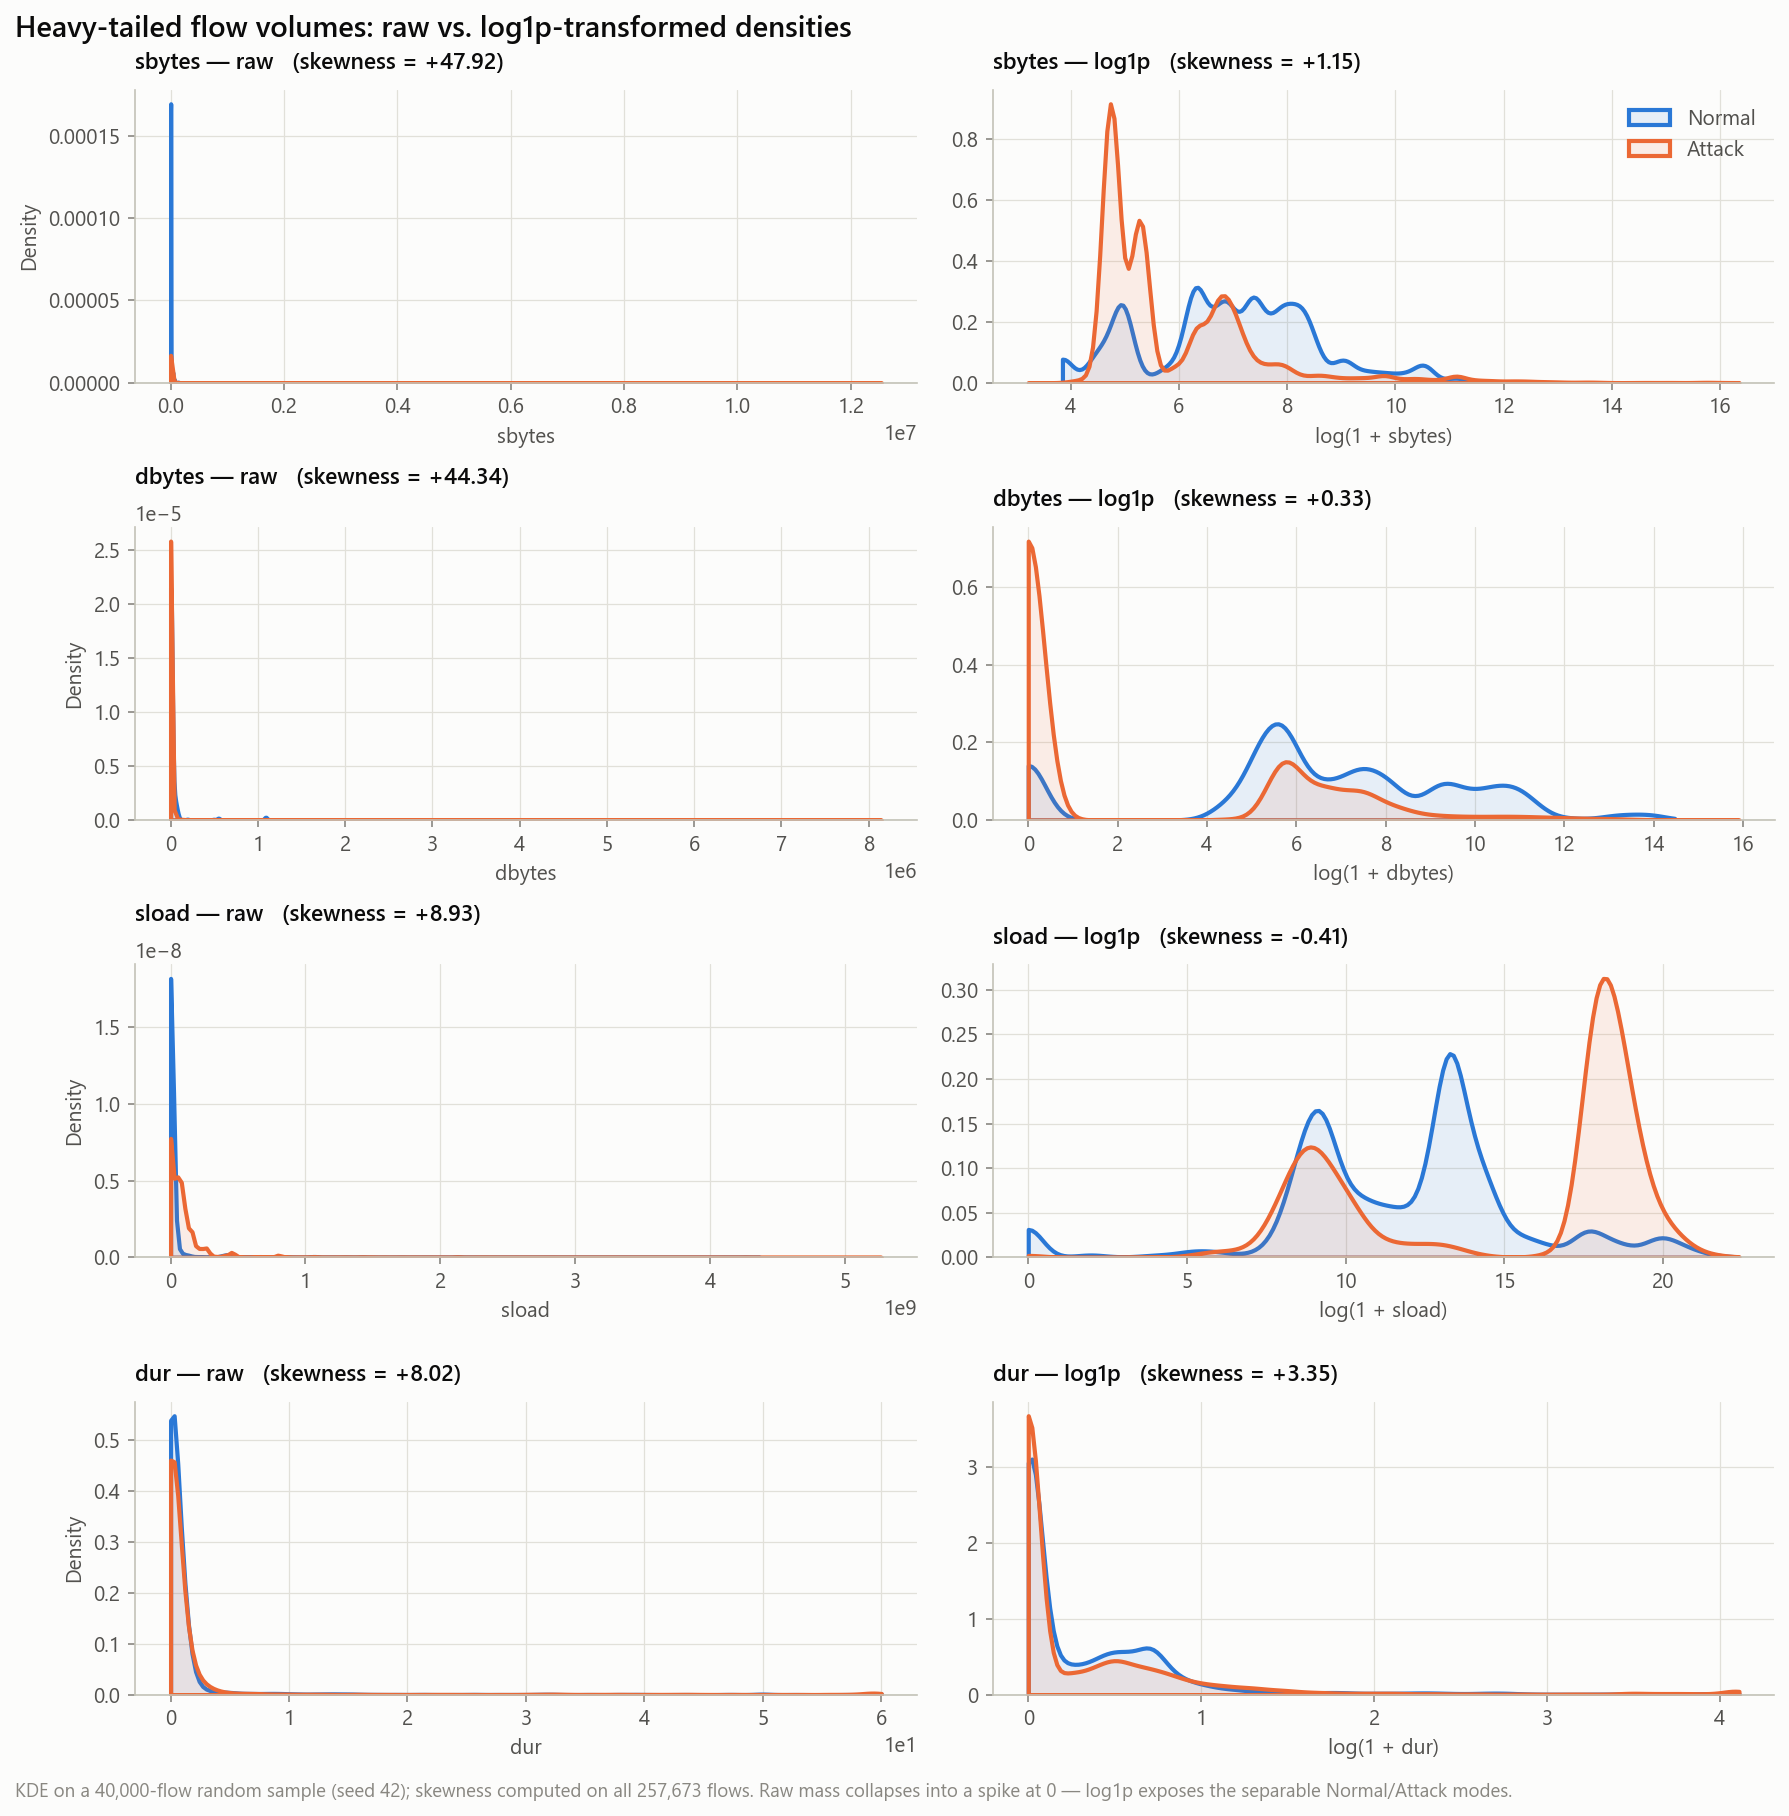

,raw skewness,log1p skewness,orders of magnitude
sbytes,47.9200,1.1500,5.8000
dbytes,44.3400,0.3300,5.7000
sload,8.9300,-0.4100,10.0000
dur,8.0200,3.3500,7.8000


In [7]:
display(Image(filename=fig_volume_skew(df, rep), width=1000))
pd.DataFrame({"raw skewness": rep["skewness_raw"], "log1p skewness": rep["skewness_log1p"],
              "orders of magnitude": rep["orders_of_magnitude"]})

**Insight → decision.** Volume features are extremely heavy-tailed (sbytes skew ≈ 48, sload spans 10 orders
of magnitude). In raw space all mass collapses into a spike at zero; after `log1p` the Normal and Attack modes
separate. Hence `log1p` on the 9 volume/timing features followed by `RobustScaler` (median/IQR, immune to DDoS
spikes).

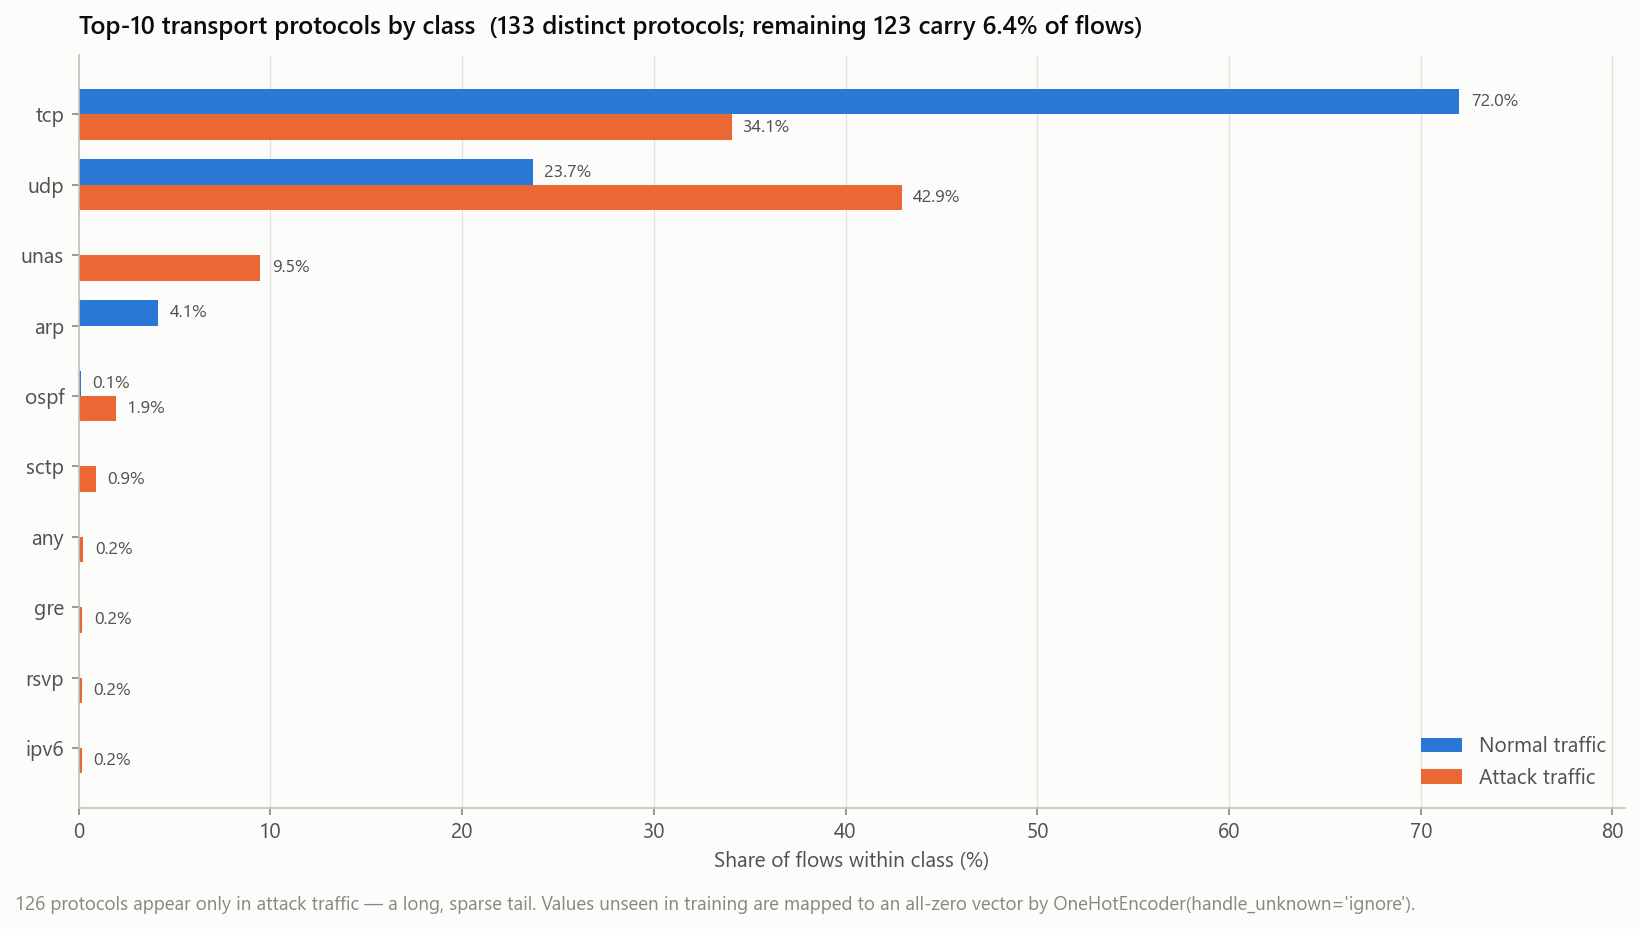

In [8]:
display(Image(filename=fig_top_protocols(df), width=1000))

**Insight → decision.** 133 protocols, but 126 of them occur *only* in attack traffic and the tail beyond the
top-10 holds just 6.4 % of flows. Rare values can be absent from the training fold, so the encoder must not crash
on them: `OneHotEncoder(handle_unknown='ignore')`.

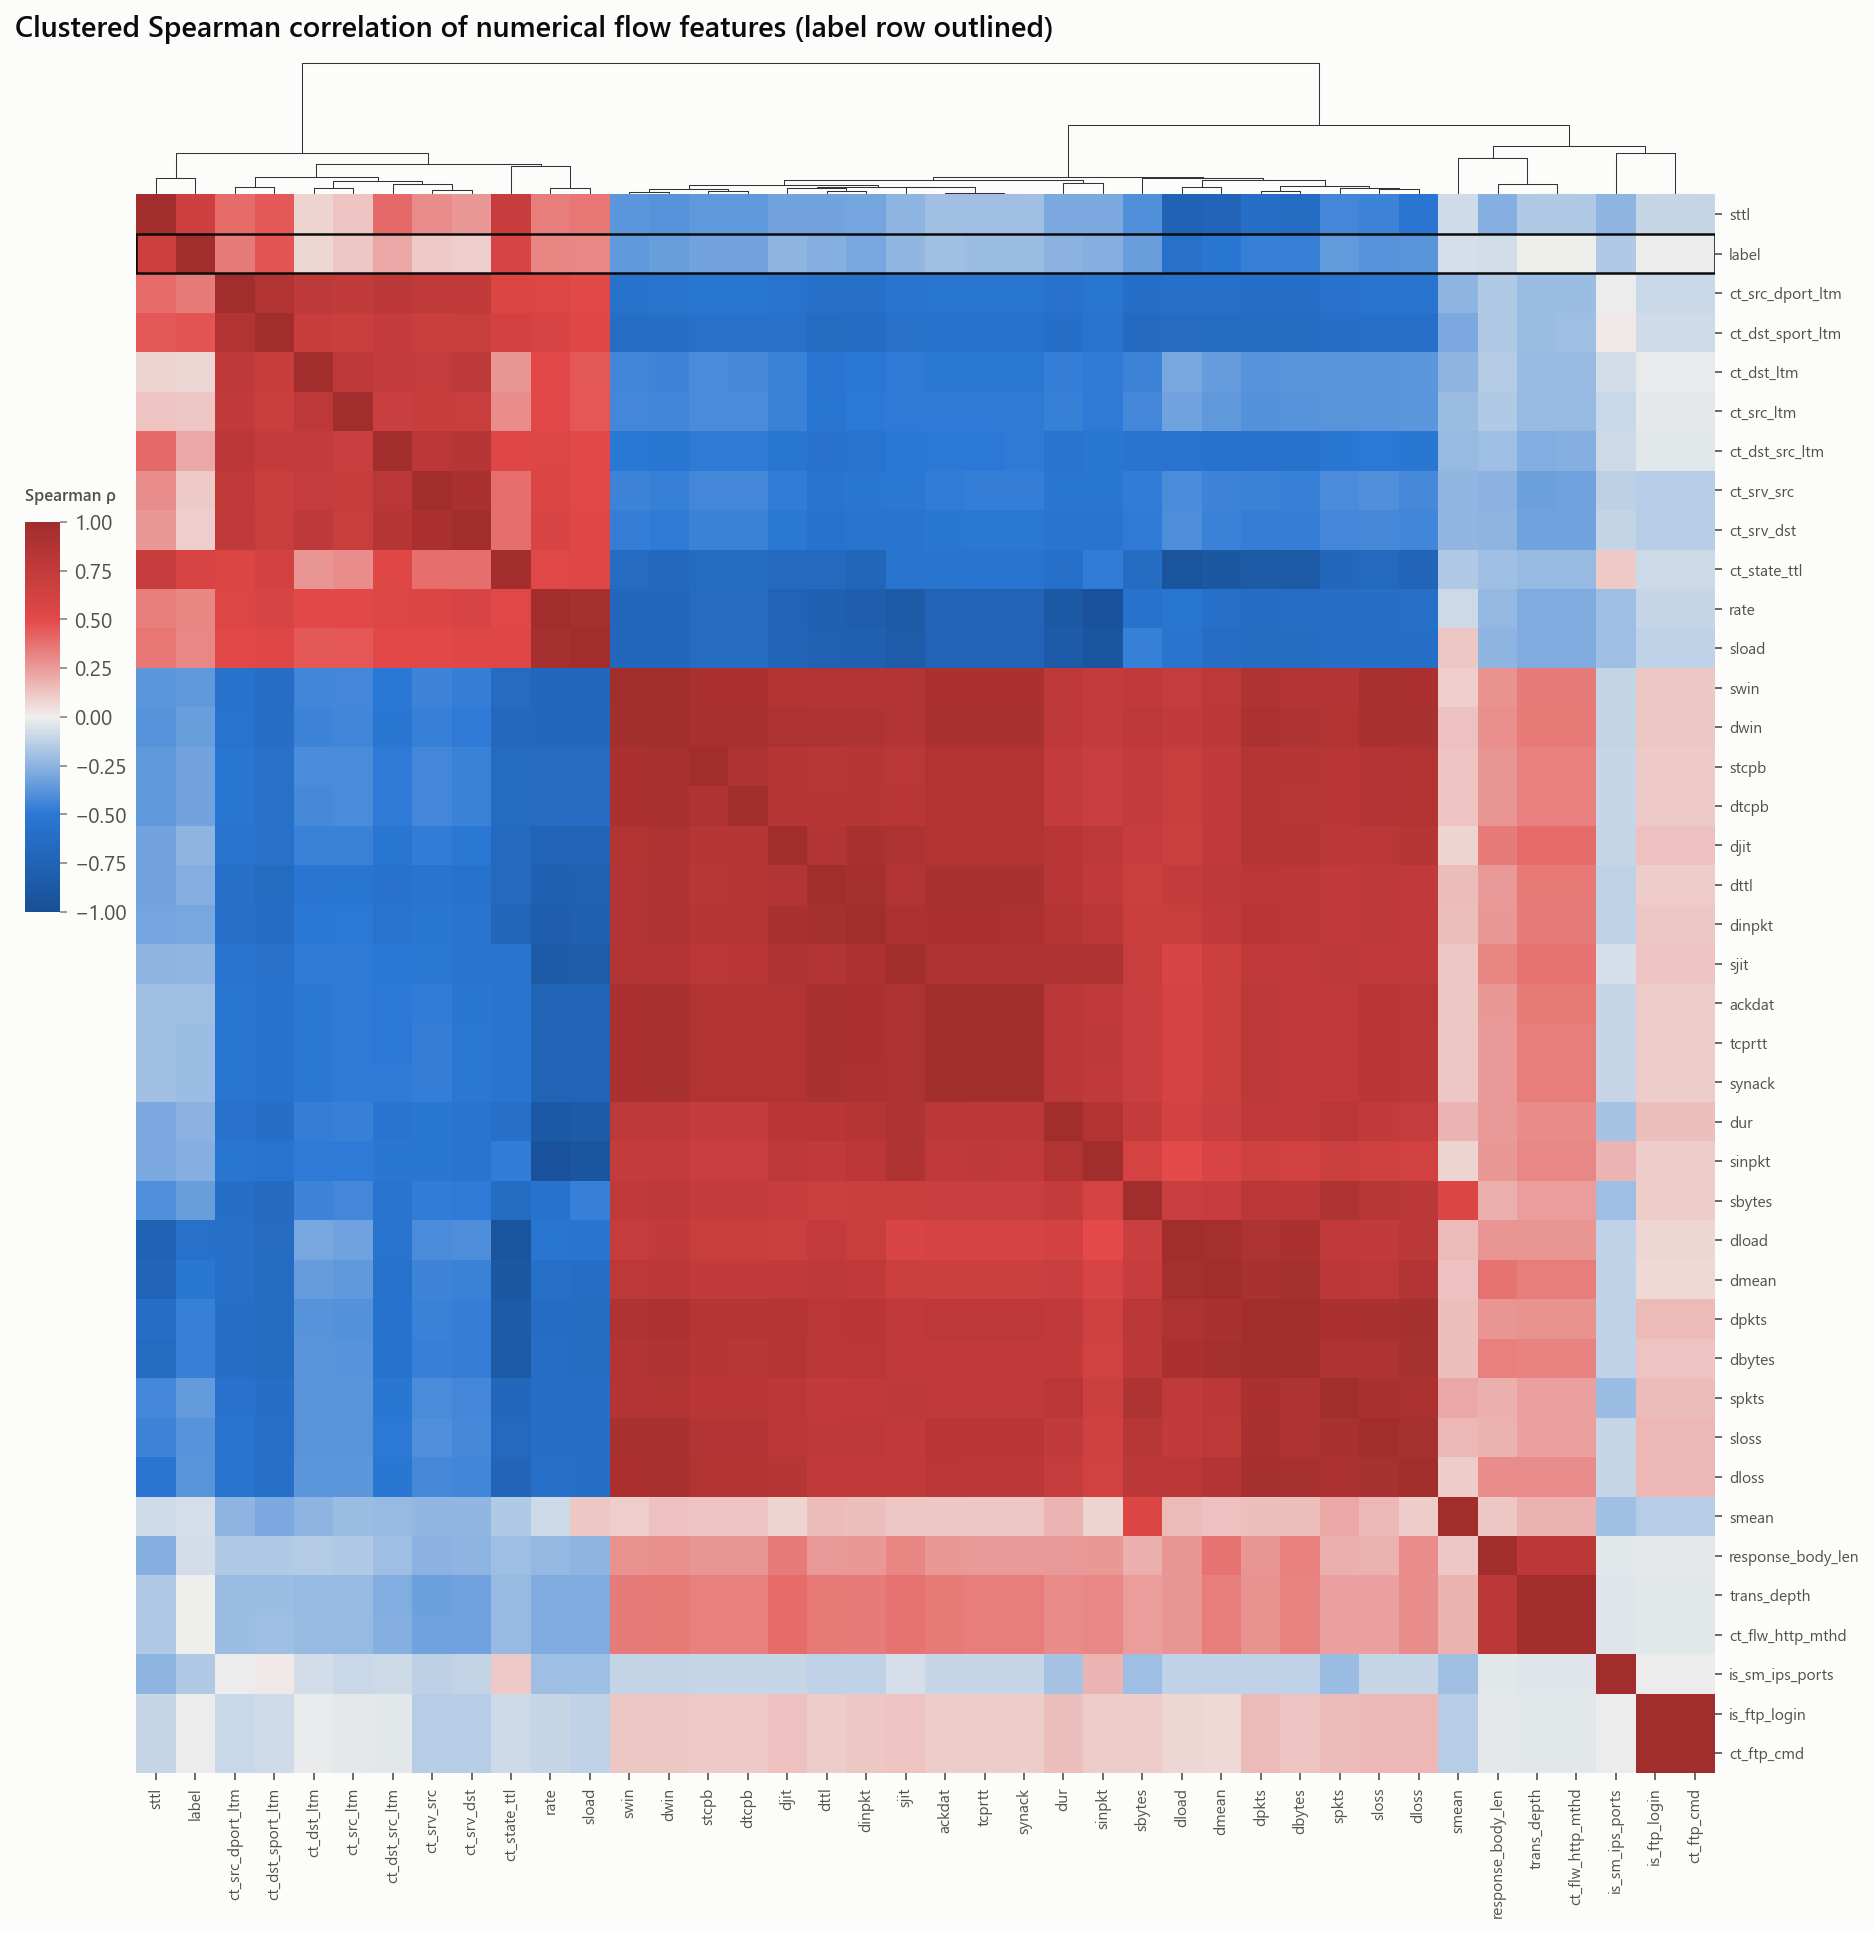

Most collinear pairs (|Spearman rho|):
is_ftp_login  ct_ftp_cmd         1.0000
trans_depth   ct_flw_http_mthd   1.0000
tcprtt        synack             0.9960
              ackdat             0.9930
dpkts         dbytes             0.9890
synack        ackdat             0.9820
swin          dwin               0.9810
dload         dmean              0.9630
dbytes        dmean              0.9610
rate          sload              0.9600


In [9]:
corr_path, top_pairs, label_corr = fig_correlation(df)
display(Image(filename=corr_path, width=900))
print("Most collinear pairs (|Spearman rho|):"); print(top_pairs.to_string())

**Insight → decision.** Several features are near-duplicates (`is_ftp_login`~`ct_ftp_cmd` ρ = 1.0,
`tcprtt`~`synack` 0.996). Tree ensembles are insensitive to collinearity, which — together with non-linearity and
explainable Gini importances — motivates the Random Forest.

## 5. Preprocessing Pipeline & Stratified Split
The split happens **before** any statistic is learned. The `ColumnTransformer` is fitted on the 80 % training fold
only and merely *applied* to the frozen 20 % test fold.

*Implementation — leak-free ColumnTransformer*

In [10]:
def safe_log1p(a):
    """log(1+x); clip(0) guards against negative artefacts (UNSW volumes are non-negative).

    Module-level (not a lambda) so the fitted pipeline is picklable by joblib.
    """
    return np.log1p(np.clip(a, 0, None))


def numeric_columns(X: pd.DataFrame) -> list[str]:
    return [c for c in X.columns if c not in CATEGORICAL and c not in LOG1P_FEATURES]


def build_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    """Unfitted transformer. Must only ever be `fit` on the training fold."""
    log_scale = Pipeline([
        ("log1p", FunctionTransformer(safe_log1p, feature_names_out="one-to-one")),
        ("scale", RobustScaler(quantile_range=(25.0, 75.0))),
    ])
    return ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL),
            ("log", log_scale, LOG1P_FEATURES),
            ("num", RobustScaler(quantile_range=(25.0, 75.0)), numeric_columns(X)),
        ],
        verbose_feature_names_out=True,
    )


def prepare_data():
    """Split + fit preprocessor on train only. Returns a dict consumed by every modelling phase."""
    X_tr, X_te, y_tr, y_te, cat_tr, cat_te = load_split()
    pre = build_preprocessor(X_tr)
    return {
        "X_tr": X_tr, "X_te": X_te, "y_tr": y_tr, "y_te": y_te, "cat_tr": cat_tr, "cat_te": cat_te,
        "pre": pre, "Xp_tr": pre.fit_transform(X_tr), "Xp_te": pre.transform(X_te),
        "feature_names": list(pre.get_feature_names_out()),
    }


def unseen_categories(pre: ColumnTransformer, X_test: pd.DataFrame) -> dict[str, list[str]]:
    """Categorical values present in the test fold but never seen by the fitted encoder."""
    ohe: OneHotEncoder = pre.named_transformers_["cat"]
    return {col: sorted(set(X_test[col].unique()) - set(cats))
            for col, cats in zip(CATEGORICAL, ohe.categories_)}

In [11]:
d = prepare_data()
Xp_tr, Xp_te, y_tr, y_te = d["Xp_tr"], d["Xp_te"], d["y_tr"], d["y_te"]
print(f"train {Xp_tr.shape}  test {Xp_te.shape}  NaN: {np.isnan(Xp_tr).sum() + np.isnan(Xp_te).sum()}")
print(f"attack rate  train {y_tr.mean():.4f}  test {y_te.mean():.4f}")
print("categorical values in test never seen in training:", unseen_categories(d["pre"], d["X_te"]))
assert Xp_tr.shape[0] == 206_138 and Xp_te.shape[0] == 51_535
pd.concat([d["cat_tr"].value_counts().rename("train"), d["cat_te"].value_counts().rename("test")], axis=1)

train (206138, 195)  test (51535, 195)  NaN: 0
attack rate  train 0.6391  test 0.6391
categorical values in test never seen in training: {'proto': [], 'service': [], 'state': ['PAR']}


,train,test
attack_cat,,
Normal,74400,18600
Generic,47097,11774
Exploits,35620,8905
Fuzzers,19397,4849
DoS,13082,3271
Reconnaissance,11189,2798
Analysis,2142,535
Backdoor,1863,466
Shellcode,1209,302


## 6. Baseline Model — Decision Tree

*Implementation — security-centric metrics (attack = positive class)*

In [12]:
def binary_metrics(y_true, y_pred, y_score=None) -> dict:
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    out = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred),           # attack detection rate
        "f1": f1_score(y_true, y_pred),
        "fpr": fp / (fp + tn),                             # false-alarm rate
        "fnr": fn / (fn + tp),                             # missed-attack rate
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }
    if y_score is not None:
        out["roc_auc"] = roc_auc_score(y_true, y_score)
    return {k: (round(float(v), 6) if isinstance(v, (float, np.floating)) else v) for k, v in out.items()}


def fmt(m: dict) -> str:
    return (f"acc={m['accuracy']:.4f}  prec={m['precision']:.4f}  recall={m['recall']:.4f}  "
            f"f1={m['f1']:.4f}  fpr={m['fpr']:.4f}  (TP={m['tp']:,} FP={m['fp']:,} FN={m['fn']:,} TN={m['tn']:,})")

In [13]:
t0 = time.perf_counter()
dt = DecisionTreeClassifier(random_state=SEED, max_depth=10, class_weight="balanced").fit(Xp_tr, y_tr)
p_dt = dt.predict_proba(Xp_te)[:, 1]
m_dt = binary_metrics(y_te, (p_dt >= 0.5).astype(int), p_dt)
print(f"trained in {time.perf_counter() - t0:.2f}s  |  {fmt(m_dt)}")

trained in 3.98s  |  acc=0.9292  prec=0.9829  recall=0.9050  f1=0.9423  fpr=0.0280  (TP=29,805 FP=520 FN=3,130 TN=18,080)


The single tree is precise but conservative: it misses **3,130** attacks (9.5% of all
attacks). That false-negative mass is the security gap an ensemble must close.

## 7. Champion Model — Tuned Random Forest
**Hyper-parameter search.** The grid search below (24 configurations × 3 stratified folds, scoring F1, on a 30 %
stratified subsample of the training fold) takes ≈ 140 s, so its recorded results are loaded from
`artifacts/rf_cv_results.csv` to keep the notebook under three minutes. `tune_rf` is the exact code that produced
them; the winning configuration is then refitted here on the full training fold.

*Implementation — hyper-parameter grid and search*

In [14]:
PARAM_GRID = {
    "n_estimators": [150, 200],
    "max_depth": [25, 30, None],
    "min_samples_split": [5, 10],
    "min_samples_leaf": [2, 4],
}


RF_FIXED = dict(max_features="sqrt", class_weight="balanced_subsample", random_state=SEED)


TUNE_FRACTION = 0.30


def tune_rf(Xp, y, cat):
    """3-fold grid search on a stratified 30 % subsample of the TRAINING fold (24 configs x 3 folds)."""
    idx, _ = train_test_split(np.arange(len(y)), train_size=TUNE_FRACTION, stratify=cat, random_state=SEED)
    gs = GridSearchCV(RandomForestClassifier(n_jobs=1, **RF_FIXED), PARAM_GRID,
                      scoring={"f1": "f1", "recall": "recall", "accuracy": "accuracy"}, refit="f1",
                      cv=StratifiedKFold(3, shuffle=True, random_state=SEED), n_jobs=-1, verbose=1)
    t0 = time.perf_counter()
    gs.fit(Xp[idx], y.iloc[idx])
    return gs, time.perf_counter() - t0, len(idx)

In [15]:
cv = pd.read_csv(ARTIFACT_DIR / "rf_cv_results.csv")
display(cv.head(8))
best = json.loads((ARTIFACT_DIR / "metrics_champion.json").read_text())["tuning"]["best_params"]
best = {k: (None if v is None else int(v)) for k, v in best.items()}
print("best params:", best)

,param_n_estimators,param_max_depth,param_min_samples_split,param_min_samples_leaf,mean_test_f1,std_test_f1,mean_test_recall,mean_test_accuracy,rank_test_f1
0,150,NaN,5,2,0.9529,0.0016,0.9443,0.9403,1
1,200,NaN,5,2,0.9529,0.0017,0.9444,0.9403,2
2,200,30.0000,5,2,0.9527,0.0016,0.9436,0.9402,3
3,150,30.0000,5,2,0.9526,0.0017,0.9438,0.9400,4
4,150,25.0000,5,2,0.9521,0.0020,0.9422,0.9394,5
5,200,25.0000,5,2,0.9521,0.0021,0.9423,0.9394,6
6,150,NaN,10,2,0.9520,0.0017,0.9409,0.9394,7
7,150,25.0000,10,2,0.9520,0.0020,0.9396,0.9395,8


best params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 150}


In [16]:
t0 = time.perf_counter()
rf = RandomForestClassifier(oob_score=True, n_jobs=-1, **best, **RF_FIXED).fit(Xp_tr, y_tr)
print(f"champion fitted in {time.perf_counter() - t0:.1f}s  |  out-of-bag accuracy {rf.oob_score_:.4f}")

champion fitted in 15.6s  |  out-of-bag accuracy 0.9488


**Why the ≥ 95 % gate is not fully reachable (evidence, not excuse).** A separate experiment
(`experiments/model_selection_validation.py`, validation slice of the training fold only) tested an alternative
tree ensemble (ExtraTrees) and five engineered ratio features against the tuned forest. None lifts recall above
**≈ 94.3 % under FPR < 5 %** (ROC-AUC ≈ 0.99). Exact duplicate flows with conflicting labels explain only 0.26 % of
error (`experiments/irreducible_error_ceiling.py`); the remainder is genuine overlap between Normal traffic and
benign-looking attack flows — above all Fuzzers (Section 10). The project therefore keeps the RF champion
(DEC-003) and reports the shortfall transparently.

## 8. Decision Threshold Optimisation (τ*)
Probabilities come from the RF's **out-of-bag** estimates: every training flow is scored only by trees that never
saw it — a free, leak-free validation set. Rule (fixed before looking at the test fold): within τ ∈ [0.30, 0.70]
choose the τ with maximum attack recall subject to FPR < 5 %, ties broken by F1.

*Implementation — threshold sweep, selection rule and calibration figure*

In [17]:
TAU_WINDOW = (0.30, 0.70)


FPR_CAP = 0.05


FPR_COLOR = "#4a3aa7"


def sweep(y, p, taus=None) -> pd.DataFrame:
    taus = np.round(np.arange(0.05, 0.951, 0.01), 2) if taus is None else taus
    rows = []
    for t in taus:
        m = binary_metrics(y, (p >= t).astype(int))
        rows.append({"tau": t, **{k: m[k] for k in ("accuracy", "precision", "recall", "f1", "fpr")}})
    return pd.DataFrame(rows)


def select_tau(sw: pd.DataFrame) -> tuple[float, str]:
    """Frozen rule: max attack recall s.t. FPR < 5 % within [0.30, 0.70]; ties broken by F1."""
    win = sw[(sw.tau >= TAU_WINDOW[0] - 1e-9) & (sw.tau <= TAU_WINDOW[1] + 1e-9)]
    feas = win[win.fpr < FPR_CAP]
    if feas.empty:
        return float(win.sort_values("f1", ascending=False).tau.iloc[0]), "fallback: max-F1 (no tau met FPR<5%)"
    return float(feas.sort_values(["recall", "f1"], ascending=False).tau.iloc[0]), "max-recall s.t. FPR<5%"


def fig_threshold(sw: pd.DataFrame, tau: float) -> str:
    fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
    for ax in (a1, a2):
        ax.axvspan(*TAU_WINDOW, color="#f0efec", zorder=0)
        ax.axvline(0.5, color=MUTED, lw=1)
        ax.axvline(tau, color=INK, lw=1.2)
    for col, color, name in [("precision", NORMAL, "Precision"), ("recall", ATTACK, "Attack recall"),
                             ("f1", ACCENT, "F1-score")]:
        a1.plot(sw.tau, sw[col], color=color, label=name)
        a1.text(sw.tau.iloc[-1] + 0.01, sw[col].iloc[-1], name, va="center", fontsize=9, color=INK_2)
    a1.axhline(0.95, color=MUTED, lw=1)
    a1.text(0.06, 0.951, "95 % target", fontsize=8.5, color=MUTED, va="bottom")
    lo = min(sw[["precision", "recall", "f1"]].min().min(), 0.90)
    a1.set_ylim(lo - 0.005, 1.0)
    a1.set_ylabel("Score (out-of-bag)")
    a1.legend(loc="lower left")
    r = sw.loc[(sw.tau - tau).abs().idxmin()]
    a1.annotate(f"τ* = {tau:.2f}\nrecall {r.recall:.4f} · F1 {r.f1:.4f}", xy=(tau, r.recall),
                xytext=(tau + 0.07, lo + 0.02), fontsize=9, color=INK,
                arrowprops=dict(arrowstyle="-", color=INK_2, lw=0.8))
    a1.set_title("Decision-threshold calibration on out-of-bag validation probabilities (test fold untouched)")

    a2.plot(sw.tau, sw.fpr, color=FPR_COLOR, label="False-alarm rate (FPR)")
    a2.axhline(FPR_CAP, color=MUTED, lw=1)
    a2.text(0.06, FPR_CAP + 0.002, "5 % FPR cap", fontsize=8.5, color=MUTED, va="bottom")
    a2.set_ylabel("FPR")
    a2.set_xlabel("Decision threshold τ   (shaded = search window 0.30–0.70; grey line = default 0.50)")
    a2.legend(loc="upper right")
    a2.set_xlim(0.05, 1.0)
    fig.tight_layout()
    return save(fig, "precision_recall_threshold.png")

tau* = 0.50  (max-recall s.t. FPR<5%)


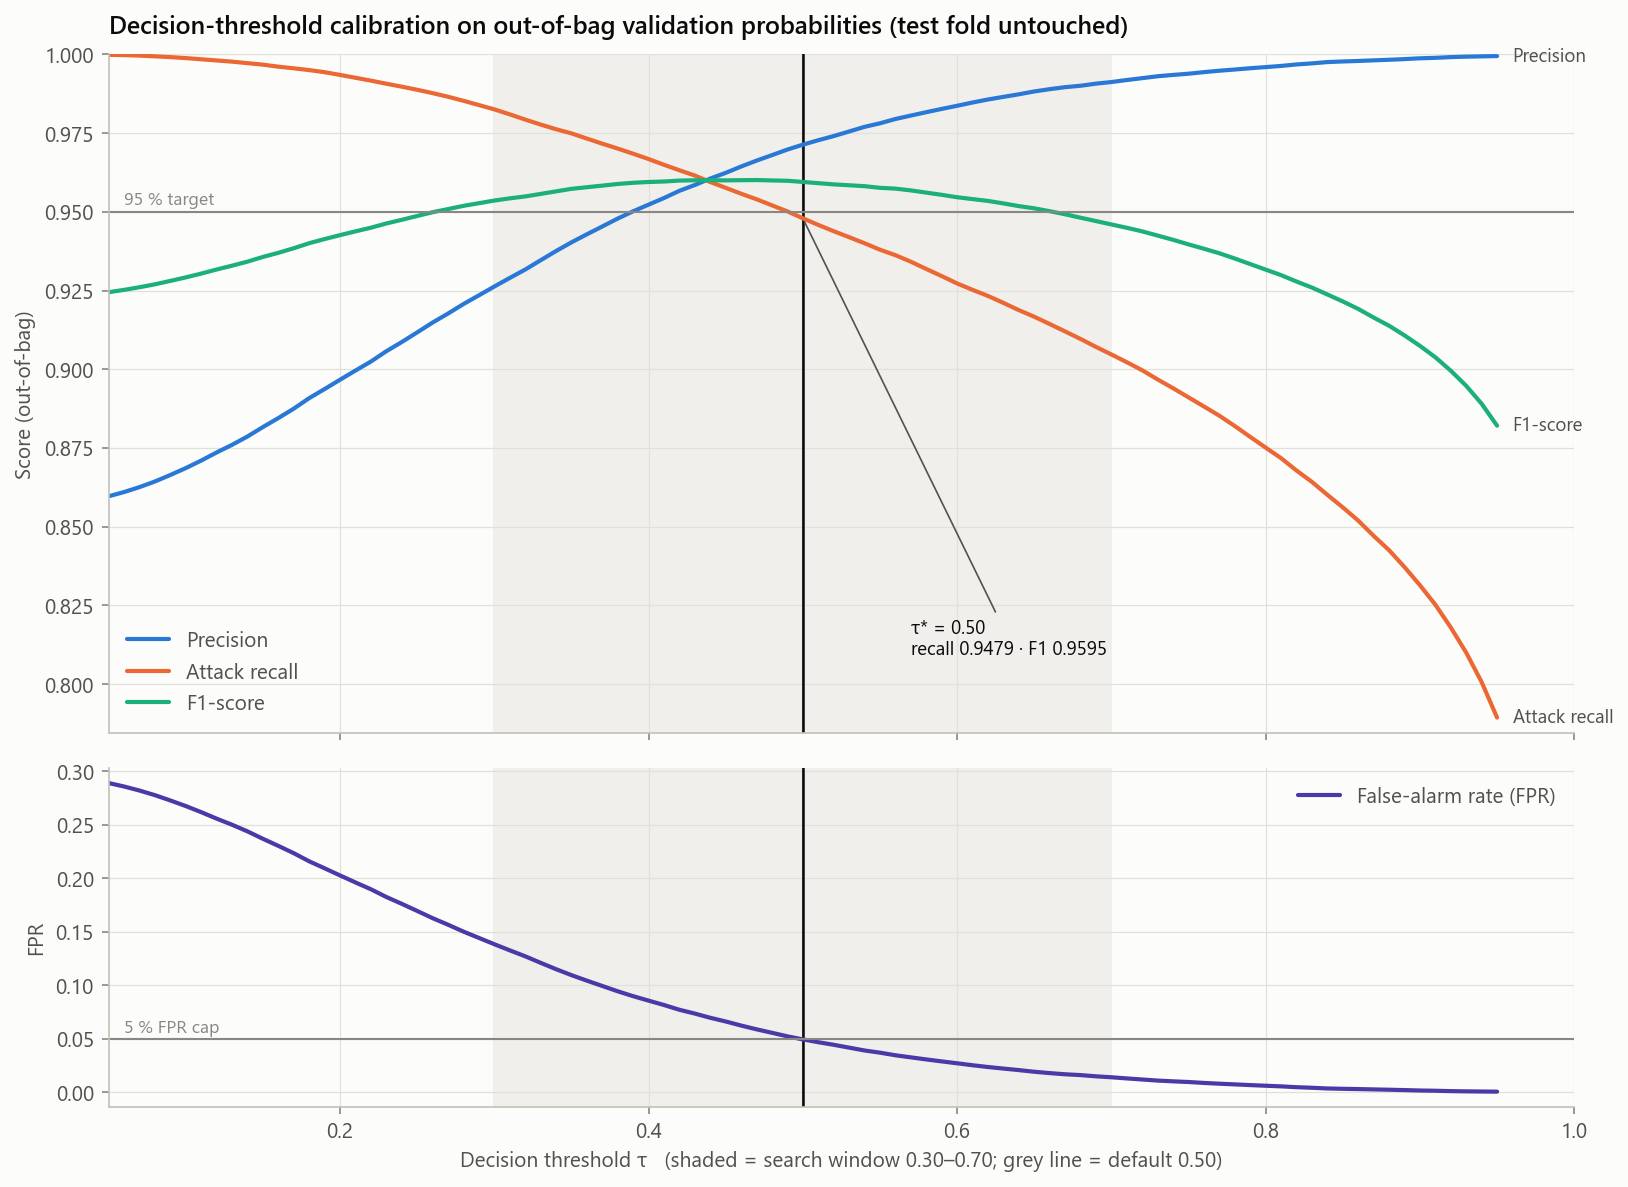

,accuracy,precision,recall,f1,fpr
tau,,,,,
0.4000,0.9478,0.9523,0.9668,0.9595,0.0858
0.4100,0.9481,0.9544,0.9649,0.9596,0.0817
0.4200,0.9486,0.9567,0.9632,0.9599,0.0773
0.4300,0.9488,0.9585,0.9615,0.9600,0.0737
0.4400,0.9489,0.9606,0.9595,0.9600,0.0698
0.4500,0.9490,0.9624,0.9576,0.9600,0.0663
0.4600,0.9491,0.9644,0.9557,0.9600,0.0625
0.4700,0.9493,0.9662,0.9540,0.9601,0.0590
0.4800,0.9492,0.9680,0.9520,0.9600,0.0558


In [18]:
oob = rf.oob_decision_function_[:, 1]; ok = ~np.isnan(oob)
sw = sweep(y_tr.to_numpy()[ok], oob[ok])
tau, rule = select_tau(sw)
print(f"tau* = {tau:.2f}  ({rule})")
display(Image(filename=fig_threshold(sw, tau), width=950))
sw[(sw.tau >= 0.40) & (sw.tau <= 0.60)].set_index("tau")

Lowering τ below 0.50 would buy recall, but OOB FPR crosses the 5 % false-alarm budget immediately — the
curve makes the trade-off explicit. The CISO can move τ along this curve as a *policy* knob.

## 9. Comparative Model Evaluation & Confusion Matrix (untouched test fold)

*Implementation — confusion-matrix figure*

In [19]:
def fig_confusion(cm: np.ndarray, tau: float) -> str:
    row = cm / cm.sum(axis=1, keepdims=True)
    fig, ax = plt.subplots(figsize=(7.6, 6.2))
    ax.imshow(row, cmap=SEQUENTIAL, vmin=0, vmax=1)
    tags = [["True Negative", "False Positive\n(false alarm)"], ["False Negative\n(missed attack)", "True Positive"]]
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{tags[i][j]}\n\n{cm[i, j]:,}\n{row[i, j]:.2%} of actual",
                    ha="center", va="center", fontsize=11, color="white" if row[i, j] > 0.5 else INK)
    ax.set_xticks([0, 1], ["Predicted Normal", "Predicted Attack"])
    ax.set_yticks([0, 1], ["Actual Normal", "Actual Attack"])
    ax.tick_params(length=0, labelsize=10.5)
    ax.grid(False)
    for s in ax.spines.values():
        s.set_visible(False)
    ax.set_title(f"Champion Random Forest — untouched test fold\n(n = {cm.sum():,} flows, τ* = {tau:.2f})")
    fig.text(0.02, 0.0, "Cell shade = share of the actual class (row-normalised).", color=MUTED, fontsize=9)
    fig.tight_layout()
    return save(fig, "confusion_matrix.png")

In [20]:
p_rf = rf.predict_proba(Xp_te)[:, 1]
m_rf = binary_metrics(y_te, (p_rf >= tau).astype(int), p_rf)
cols = ["accuracy", "precision", "recall", "f1", "fpr", "roc_auc", "tp", "fp", "fn", "tn"]
table = pd.DataFrame([m_dt, m_rf], index=["Decision Tree @0.50", f"Tuned RF @{tau:.2f} (champion)"])[cols]
display(table)
gates = {"accuracy>=95%": m_rf["accuracy"] >= .95, "recall>=95%": m_rf["recall"] >= .95,
         "F1>=95%": m_rf["f1"] >= .95, "FPR<5%": m_rf["fpr"] < .05}
print("Champion acceptance gates:", gates)

,accuracy,precision,recall,f1,fpr,roc_auc,tp,fp,fn,tn
Decision Tree @0.50,0.9292,0.9829,0.9050,0.9423,0.0280,0.9859,29805,520,3130,18080
Tuned RF @0.50 (champion),0.9471,0.9705,0.9460,0.9581,0.0509,0.9915,31155,947,1780,17653


Champion acceptance gates: {'accuracy>=95%': False, 'recall>=95%': False, 'F1>=95%': True, 'FPR<5%': False}


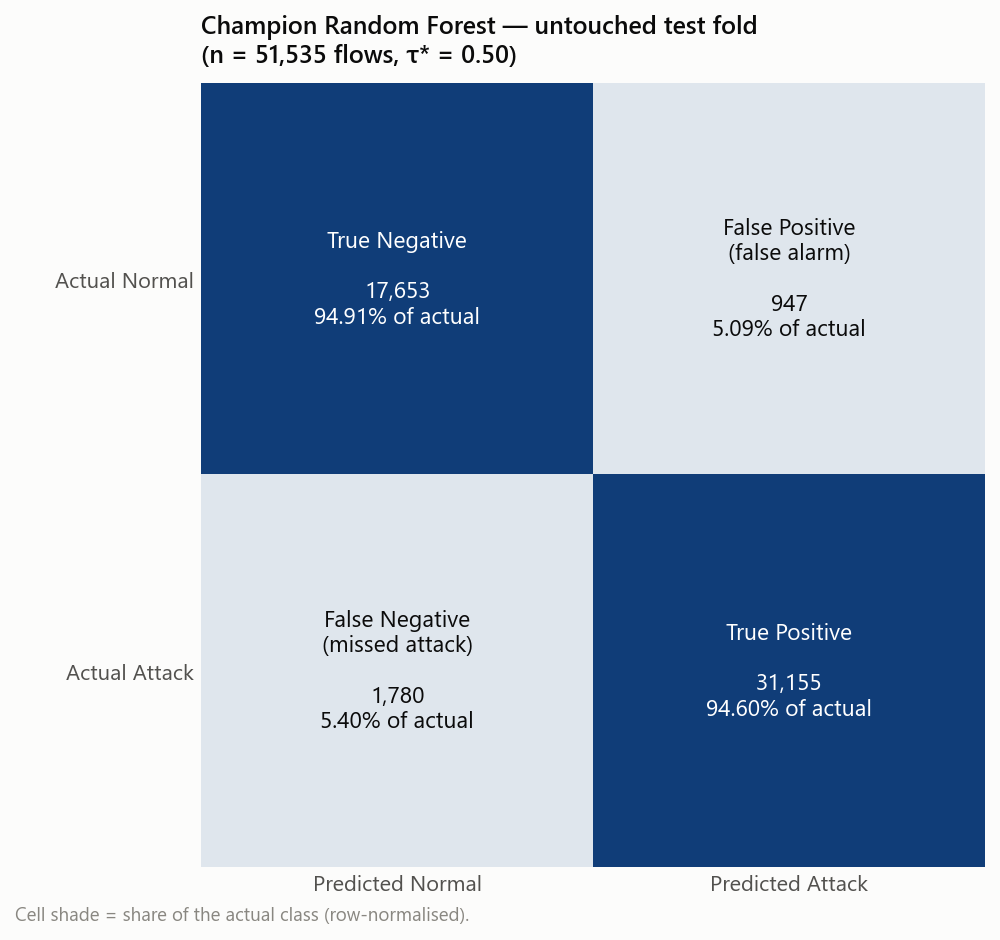

In [21]:
cm = np.array([[m_rf["tn"], m_rf["fp"]], [m_rf["fn"], m_rf["tp"]]])
display(Image(filename=fig_confusion(cm, tau), width=620))

**Operational trade-off.** Per 10,000 flows the champion raises ≈ 184
false alarms (analyst triage time) and misses ≈ 345 attacks (breach risk).
A false positive costs minutes of SOC effort; a false negative can cost persistence, lateral movement and data
exfiltration — so recall is weighted above precision, within an explicit false-alarm budget.

## 10. Granular 9-Family Attack Recall & Security Critique

*Implementation — per-family recall with Wilson intervals*

In [22]:
FAMILIES = ["Generic", "Exploits", "Fuzzers", "DoS", "Reconnaissance", "Analysis", "Backdoor", "Shellcode", "Worms"]


def wilson(k: int, n: int, z: float = 1.96) -> tuple[float, float]:
    """Wilson score interval — honest uncertainty for small families (Worms n=35)."""
    p = k / n
    den = 1 + z * z / n
    centre = (p + z * z / (2 * n)) / den
    half = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return centre - half, centre + half


def recall_table(pred: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for fam in FAMILIES:
        sub = pred[pred.attack_cat == fam]
        k, n = int(sub.rf_pred.sum()), len(sub)
        lo, hi = wilson(k, n)
        rows.append({"family": fam, "support": n, "detected": k, "missed": n - k, "recall": k / n,
                     "ci_lo": lo, "ci_hi": hi, "mean_attack_proba": sub.rf_proba.mean()})
    t = pd.DataFrame(rows)
    t["share_of_all_misses"] = t.missed / t.missed.sum()
    return t


def fig_recall(t: pd.DataFrame) -> str:
    t = t.sort_values("recall").reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(11, 6))
    y = np.arange(len(t))
    ax.barh(y, t.recall * 100, color=ATTACK, height=0.6)
    # clip: at recall = 1.0 float rounding can put the Wilson bound a hair inside the point estimate
    err = np.clip([(t.recall - t.ci_lo) * 100, (t.ci_hi - t.recall) * 100], 0, None)
    ax.errorbar(t.recall * 100, y, xerr=err,
                fmt="none", ecolor=INK_2, elinewidth=1, capsize=3)
    for i, r in t.iterrows():
        ax.text(101.5, i, f"{r.recall:.2%}   {r.detected:,} / {r.support:,}", va="center", fontsize=9, color=INK_2)
    ax.axvline(95, color=MUTED, lw=1)
    ax.text(95, len(t) - 0.35, "95 % target", ha="center", fontsize=8.5, color=MUTED)
    ax.set_yticks(y, t.family)
    ax.set_xlim(0, 125)
    ax.set_xticks(range(0, 101, 20))
    ax.set_xlabel("Attack recall / detection rate (%) — whiskers: 95 % Wilson CI")
    ax.grid(axis="y", visible=False)
    ax.set_title("Per-family attack detection rate — champion RF on the untouched test fold")
    fig.tight_layout()
    return save(fig, "attack_recall_breakdown.png")

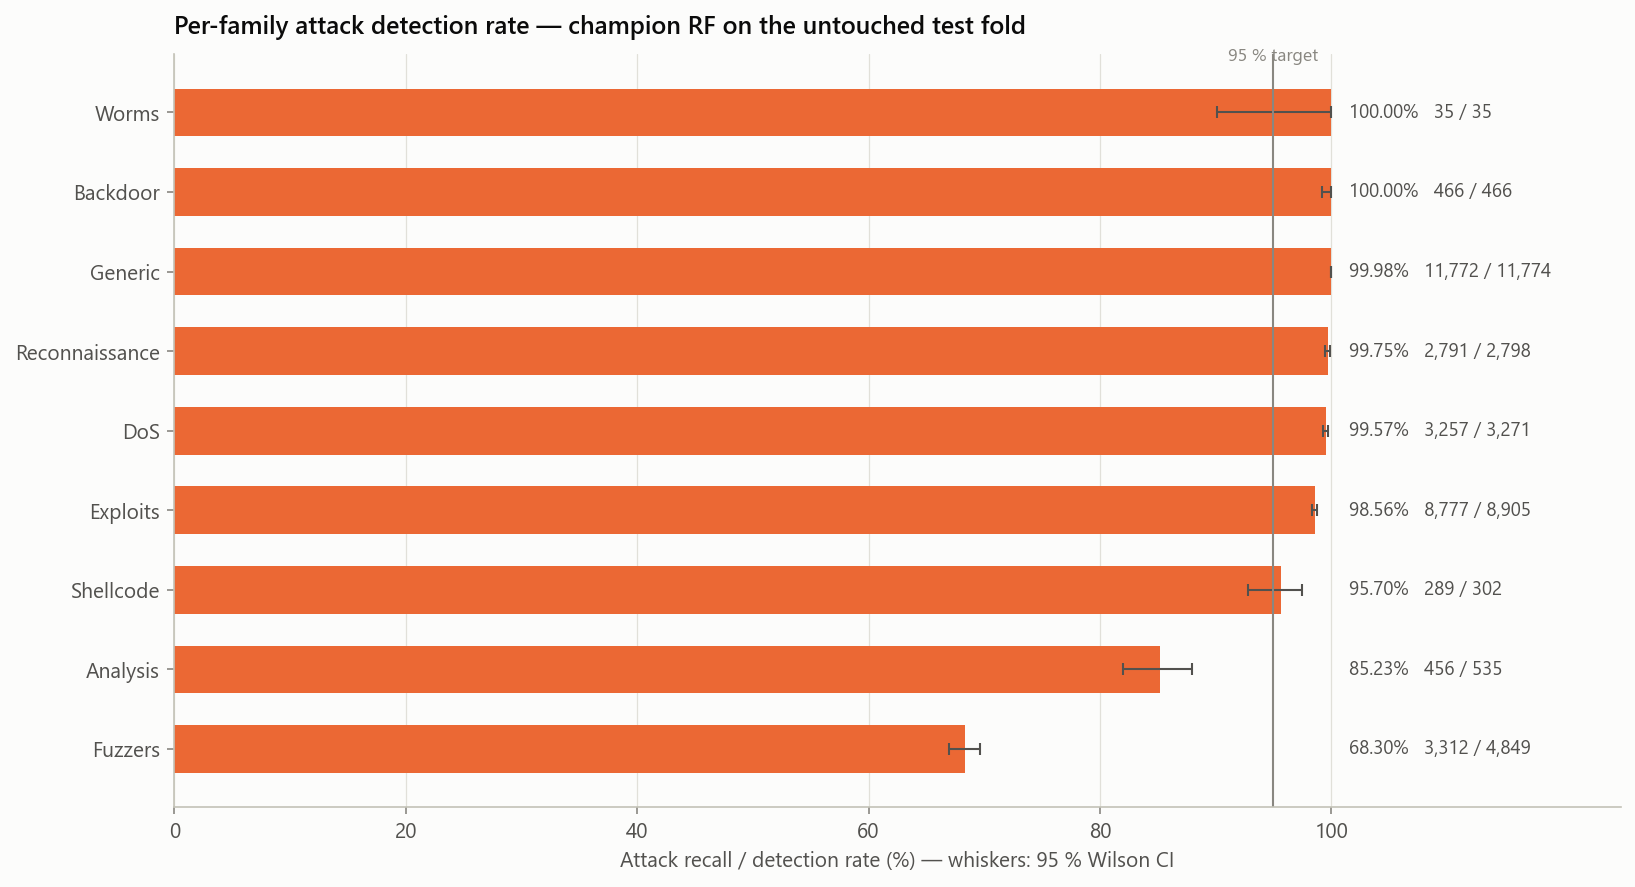

,family,support,detected,missed,recall,ci_lo,ci_hi,share_of_all_misses
2,Fuzzers,4849,3312,1537,0.6830,0.6698,0.6960,0.8635
5,Analysis,535,456,79,0.8523,0.8198,0.8799,0.0444
7,Shellcode,302,289,13,0.9570,0.9278,0.9747,0.0073
1,Exploits,8905,8777,128,0.9856,0.9829,0.9879,0.0719
3,DoS,3271,3257,14,0.9957,0.9928,0.9974,0.0079
4,Reconnaissance,2798,2791,7,0.9975,0.9948,0.9988,0.0039
0,Generic,11774,11772,2,0.9998,0.9994,1.0000,0.0011
6,Backdoor,466,466,0,1.0000,0.9918,1.0000,0.0000
8,Worms,35,35,0,1.0000,0.9011,1.0000,0.0000


In [23]:
pred = pd.DataFrame({"attack_cat": d["cat_te"], "rf_pred": (p_rf >= tau).astype(int), "rf_proba": p_rf})
t = recall_table(pred)
assert t.support.sum() == int(y_te.sum()) and t.missed.sum() == m_rf["fn"]
display(Image(filename=fig_recall(t), width=950))
t.sort_values("recall")[["family", "support", "detected", "missed", "recall", "ci_lo", "ci_hi", "share_of_all_misses"]]

**Critical security analysis.** Only 2 of 9 families fall below 95 %
recall: **Fuzzers** (68.3%), **Analysis** (85.2%).

* **Fuzzers are the dominant blind spot** — 1,537 missed flows, **86% of all
  false negatives**. Fuzzing floods a service with malformed or random input to find crashable code; at the flow
  level many fuzzing sessions are short, low-volume exchanges over ordinary services whose byte, TTL and timing
  statistics match benign clients. The ceiling analysis corroborates this: the *only* exact feature-vector
  collisions between classes in the dataset are Normal ↔ Fuzzers. **Security implication:** an adversary fuzzing an
  internet-facing service for a zero-day would largely go unnoticed, so detection shifts from the discovery phase
  to the far more damaging exploitation phase.
* **Analysis** (79 of 535 missed) covers port scans, spam and HTML-file penetration
  probes — missed flows mean vulnerability probing goes unlogged.
* **Rare ≠ undetected.** Contrary to the usual expectation, the rarest families — **Worms (100%) and
  Backdoor (100%)** — are fully detected: their TTL/state fingerprints are highly distinctive. Worms'
  Wilson interval still spans [90.1%, 100 %] because only 35 test flows exist, and a single
  missed worm would be disproportionately dangerous because it self-propagates.
* **Mitigation roadmap.** (i) payload-aware features (DPI, TLS/JA3 fingerprints) for Fuzzers and Analysis, which are
  indistinguishable at flow level; (ii) family-specific or cost-sensitive thresholds; (iii) correlate ML alerts with
  signature IDS and host EDR telemetry (defence in depth) rather than relying on a single detector.

## 11. Feature Importance & SOC Explainability

*Implementation — feature naming and importance figure*

In [24]:
def pretty(name: str) -> str:
    kind, _, feat = name.partition("__")
    if kind == "cat":
        col, _, val = feat.partition("_")
        return f"{col} = {val}"
    return f"{feat} (log1p)" if kind == "log" else feat


def fig_importance(imp: pd.Series) -> str:
    top = imp.head(15).iloc[::-1]
    fig, ax = plt.subplots(figsize=(10, 6.5))
    ax.barh([pretty(n) for n in top.index], top.values, color=NORMAL, height=0.6)
    for i, v in enumerate(top.values):
        ax.text(v + top.max() * 0.01, i, f"{v:.3f}", va="center", fontsize=8.5, color=INK_2)
    ax.set_xlim(0, top.max() * 1.12)
    ax.set_xlabel("Mean decrease in Gini impurity")
    ax.grid(axis="y", visible=False)
    ax.set_title("Top-15 Gini feature importances — tuned Random Forest champion")
    fig.text(0.01, -0.02, f"Top-15 features account for {top.sum():.1%} of total importance across "
             f"{len(imp)} processed features.", color=MUTED, fontsize=9)
    fig.tight_layout()
    return save(fig, "feature_importance.png")

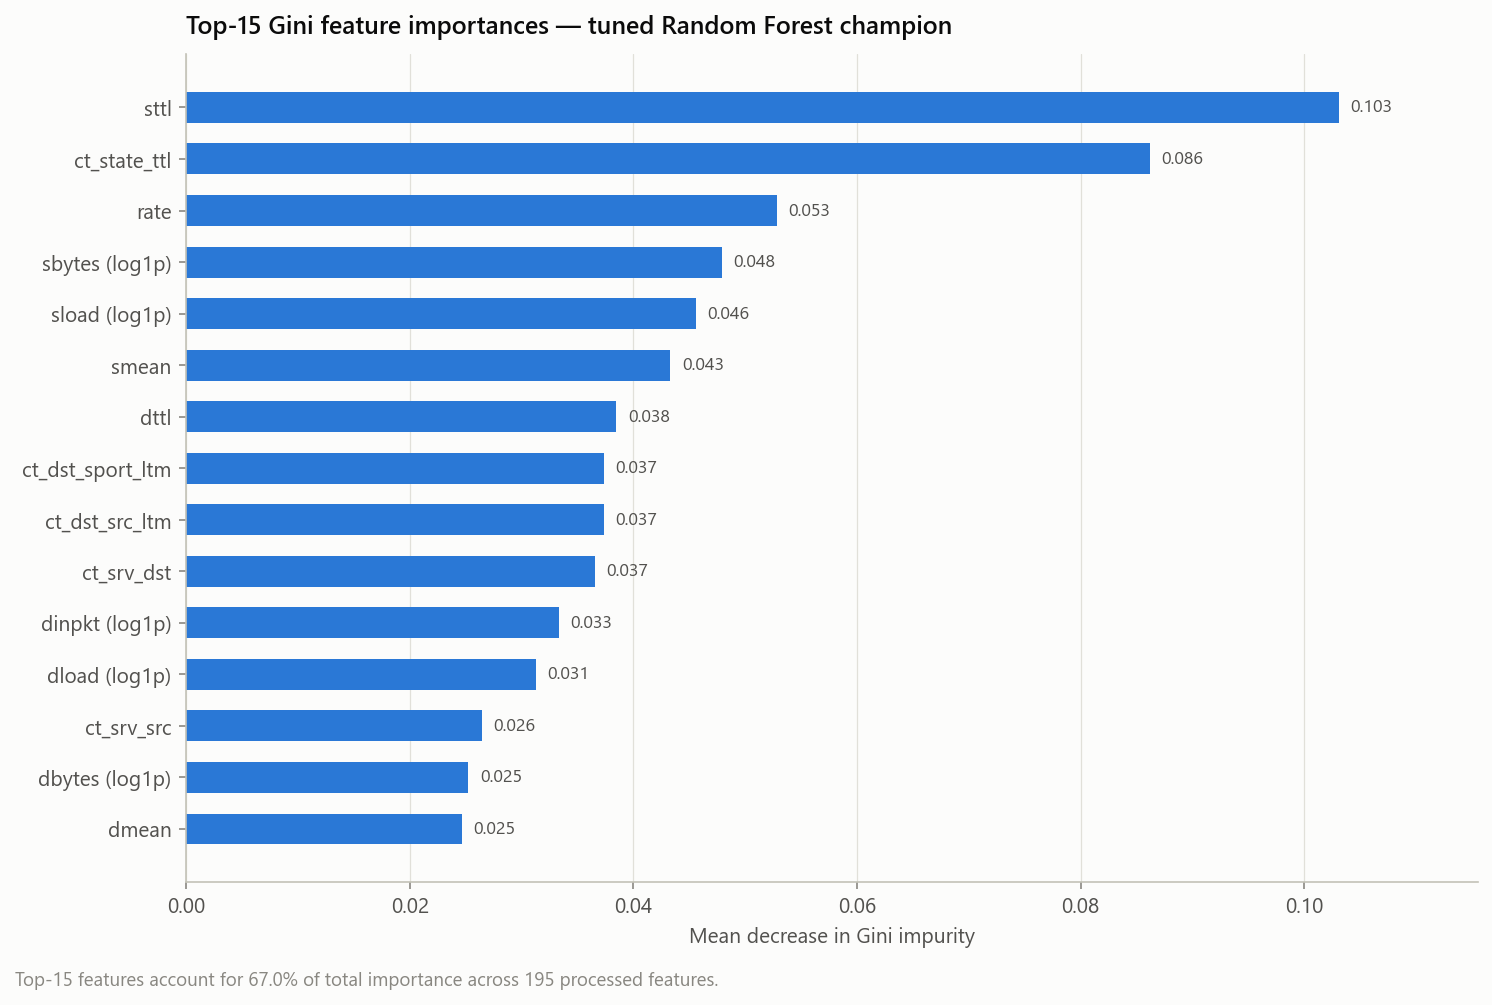

,gini_importance
sttl,0.1031
ct_state_ttl,0.0862
rate,0.0528
sbytes (log1p),0.0479
sload (log1p),0.0456
smean,0.0433
dttl,0.0385
ct_dst_sport_ltm,0.0374
ct_dst_src_ltm,0.0374
ct_srv_dst,0.0366


In [25]:
imp = pd.Series(rf.feature_importances_, index=d["feature_names"]).sort_values(ascending=False)
display(Image(filename=fig_importance(imp), width=900))
imp.head(15).rename(index=pretty).to_frame("gini_importance")

**Reading the model like a SOC analyst.** Time-to-live features (`sttl`, `ct_state_ttl`, `dttl`) dominate:
attack tooling in the testbed emits packets with characteristic initial TTLs and TTL/state combinations that benign
hosts rarely produce — the same fingerprint used to spot OS/tool artefacts in threat hunting. Volume and rate
features (`sbytes`, `smean`, `dbytes`, `sload`) capture payload anomalies — oversized requests typical of
buffer-overflow exploits and tiny, uniform probes typical of scans and fuzzing. Connection-count features
(`ct_srv_dst`, `ct_dst_src_ltm`, `ct_dst_sport_ltm`) measure fan-out to services and ports over the last 100
connections — the behavioural signature of port scanning and reconnaissance.

## 12. Real-Time Threat Detection Benchmark & Streaming SIEM Simulation

*Implementation — latency benchmark, stage-2 family classifier and streaming SIEM engine*

In [26]:
N_BENCH = 10_000


BATCH_PLAN = {1: 1_000, 10: 2_000, 100: 10_000, 1_000: 10_000, 10_000: 10_000}


SEVERITY = {"Worms": "CRITICAL", "Backdoor": "CRITICAL", "Shellcode": "CRITICAL", "Exploits": "CRITICAL",
            "DoS": "HIGH", "Generic": "HIGH", "Analysis": "HIGH", "Fuzzers": "MEDIUM", "Reconnaissance": "MEDIUM"}


ACTION = {"CRITICAL": "TCP RST Packet Dispatched | Flow Blocked",
          "HIGH": "TCP RST Packet Dispatched | Flow Blocked",
          "MEDIUM": "Source Rate-Limited | SOC Ticket Opened"}


SIEM_MIX = {"Normal": 6, "Exploits": 3, "DoS": 3, "Fuzzers": 3, "Worms": 2, "Generic": 1,
            "Reconnaissance": 1, "Backdoor": 1}


def infer(pre, rf, X) -> np.ndarray:
    return rf.predict_proba(pre.transform(X))[:, 1]


def benchmark(pre, rf, X: pd.DataFrame) -> tuple[pd.DataFrame, dict, dict]:
    """End-to-end (preprocess + predict_proba) timing on ONE core, per batch size."""
    rf.n_jobs = 1
    infer(pre, rf, X.iloc[:100])  # warm-up
    rows, per_call = [], {}
    for bs, n in BATCH_PLAN.items():
        times = []
        for s in range(0, n, bs):
            t0 = time.perf_counter()
            infer(pre, rf, X.iloc[s:s + bs])
            times.append(time.perf_counter() - t0)
        times = np.array(times)
        per_call[bs] = times
        rows.append({"batch_size": bs, "flows": n, "calls": len(times), "total_s": times.sum(),
                     "us_per_flow_mean": times.sum() / n * 1e6,
                     "us_per_flow_p50": np.median(times / bs) * 1e6,
                     "us_per_flow_p95": np.percentile(times / bs, 95) * 1e6,
                     "flows_per_s": n / times.sum()})
    rf.n_jobs = -1
    infer(pre, rf, X.iloc[:1000])
    full = []
    for _ in range(5):
        t0 = time.perf_counter()
        infer(pre, rf, X.iloc[:N_BENCH])
        full.append(time.perf_counter() - t0)
    all_cores = {"flows": N_BENCH, "repeats": 5, "median_s": float(np.median(full)),
                 "us_per_flow": float(np.median(full) / N_BENCH * 1e6),
                 "flows_per_s": float(N_BENCH / np.median(full))}
    return pd.DataFrame(rows), per_call, all_cores


def fig_latency(tab: pd.DataFrame, per_call: dict, all_cores: dict) -> str:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5.2), gridspec_kw={"width_ratios": [1.2, 1, 1]})
    a, b, c = axes
    x = np.arange(len(tab))
    a.bar(x, tab.flows_per_s, color=NORMAL, width=0.55)
    a.set_yscale("log")
    for i, v in enumerate(tab.flows_per_s):
        a.text(i, v * 1.15, f"{v:,.0f}", ha="center", fontsize=9, color=INK_2)
    a.set_xticks(x, [f"{b:,}" for b in tab.batch_size])
    a.set_xlabel("Micro-batch size (flows per inference call)")
    a.set_ylabel("Throughput (flows / s, log scale) — 1 CPU core")
    a.axhline(10_000, color=MUTED, lw=1)
    a.text(-0.4, 10_000 * 1.1, "10k flows/s target", fontsize=8.5, color=MUTED)
    a.set_ylim(tab.flows_per_s.min() / 2, tab.flows_per_s.max() * 4)
    a.grid(axis="x", visible=False)
    a.set_title("A. Throughput vs. micro-batch size")

    us = per_call[100] / 100 * 1e6
    b.hist(us, bins=25, color=NORMAL)
    b.axvline(np.median(us), color=INK, lw=1.2)
    b.text(np.median(us), b.get_ylim()[1] * 0.92, f"  median {np.median(us):.1f} µs/flow", fontsize=9, color=INK)
    b.set_xlabel("Amortised latency per flow (µs), batch = 100")
    b.set_ylabel("Inference calls")
    b.set_title("B. Micro-batched latency distribution")

    ms = per_call[1] * 1e3
    c.hist(ms, bins=30, color=ATTACK)
    c.axvline(np.median(ms), color=INK, lw=1.2)
    c.text(np.median(ms), c.get_ylim()[1] * 0.92, f"  median {np.median(ms):.2f} ms", fontsize=9, color=INK)
    c.set_xlabel("Single-flow latency (ms), batch = 1")
    c.set_ylabel("Flows")
    c.set_title("C. One-at-a-time latency (worst case)")
    fig.suptitle("Real-time feasibility of the champion pipeline (preprocessing + Random Forest inference)",
                 x=0.01, ha="left", fontsize=14, fontweight="semibold", color=INK)
    fig.text(0.01, -0.03, f"All 16 cores, single 10,000-flow batch: {all_cores['us_per_flow']:.2f} µs/flow · "
             f"{all_cores['flows_per_s']:,.0f} flows/s (median of 5).  Timings are wall-clock, end-to-end, "
             "on an Intel i7-11800H.", color=MUTED, fontsize=9)
    fig.tight_layout()
    return save(fig, "latency_throughput.png")


def train_family_classifier(pre, X_tr, cat_tr, X_te, cat_te):
    """Stage-2 SIEM enrichment: which attack family, given the flow was flagged malicious."""
    tr, te = cat_tr != "Normal", cat_te != "Normal"
    clf = RandomForestClassifier(n_estimators=100, min_samples_leaf=2, class_weight="balanced_subsample",
                                 random_state=SEED, n_jobs=-1)
    t0 = time.perf_counter()
    clf.fit(pre.transform(X_tr[tr]), cat_tr[tr])
    secs = time.perf_counter() - t0
    pred = clf.predict(pre.transform(X_te[te]))
    rep = {"train_attack_rows": int(tr.sum()), "test_attack_rows": int(te.sum()), "train_seconds": round(secs, 1),
           "accuracy": round(accuracy_score(cat_te[te], pred), 4),
           "macro_f1": round(f1_score(cat_te[te], pred, average="macro"), 4),
           "recall_by_family": {f: round(float(v), 4) for f, v in zip(
               clf.classes_, recall_score(cat_te[te], pred, average=None, labels=clf.classes_))}}
    return clf, rep


def siem_stream(pre, rf, fam, tau, X_te, cat_te) -> list[str]:
    rng = np.random.default_rng(SEED)
    idx = np.concatenate([rng.choice(np.flatnonzero(cat_te.to_numpy() == c), k, replace=False)
                          for c, k in SIEM_MIX.items()])
    rng.shuffle(idx)
    rf.n_jobs = fam.n_jobs = 1  # single-flow scoring: a thread pool per call costs ~20 ms of pure overhead
    lines = []
    for i in idx:
        row = X_te.iloc[[i]]
        t0 = time.perf_counter()
        z = pre.transform(row)
        p = rf.predict_proba(z)[0, 1]
        family = fam.predict(z)[0] if p >= tau else None
        lat_us = (time.perf_counter() - t0) * 1e6
        ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S.%f")[:-3]
        truth = cat_te.iloc[i]
        head = f"{row.proto.iloc[0]}/{row.service.iloc[0]}/{row.state.iloc[0]}"
        if family is not None:
            sev = SEVERITY[family]
            verdict = "TP" if truth != "Normal" else "FP — FALSE ALARM"
            fam_ok = "match" if family == truth else "MISMATCH"  # ASCII: Consolas lacks check-mark glyphs
            lines += [f"[{ts}] [ALERT] [{sev}] Malicious Flow #{i} Detected!  ({head})",
                      f"  ├─ Attack Category : {family}   (stage-2 guess: {fam_ok}; ground truth: {truth})",
                      f"  ├─ Detection       : {verdict}",
                      f"  ├─ Confidence Score: {p:.2%}   (τ* = {tau:.2f})",
                      f"  ├─ Latency         : {lat_us:,.2f} microseconds",
                      f"  └─ Action Taken    : {ACTION[sev]}"]
        else:
            verdict = "TN" if truth == "Normal" else "FN — MISSED ATTACK"
            lines += [f"[{ts}] [INFO ] [ALLOW] Flow #{i} classified benign  ({head})",
                      f"  └─ P(attack) {p:.2%} · latency {lat_us:,.2f} µs · ground truth: {truth} → {verdict}"]
        time.sleep(0.05)  # simulated inter-arrival gap on the feed
    return lines

,flows,calls,total_s,us_per_flow_mean,us_per_flow_p50,us_per_flow_p95,flows_per_s
batch_size,,,,,,,
1,1000,1000,6.9378,"6,937.7760","6,859.7500","7,679.2150",144.1384
10,2000,200,1.4735,736.7524,728.0950,807.2610,"1,357.3081"
100,10000,100,1.0537,105.3744,104.1460,115.9680,"9,489.9674"
1000,10000,10,0.3102,31.0190,31.0345,31.6222,"32,238.2848"
10000,10000,1,0.1842,18.4170,18.4170,18.4170,"54,297.7777"


all cores, one 10,000-flow batch: 6.30 us/flow = 158,757 flows/s


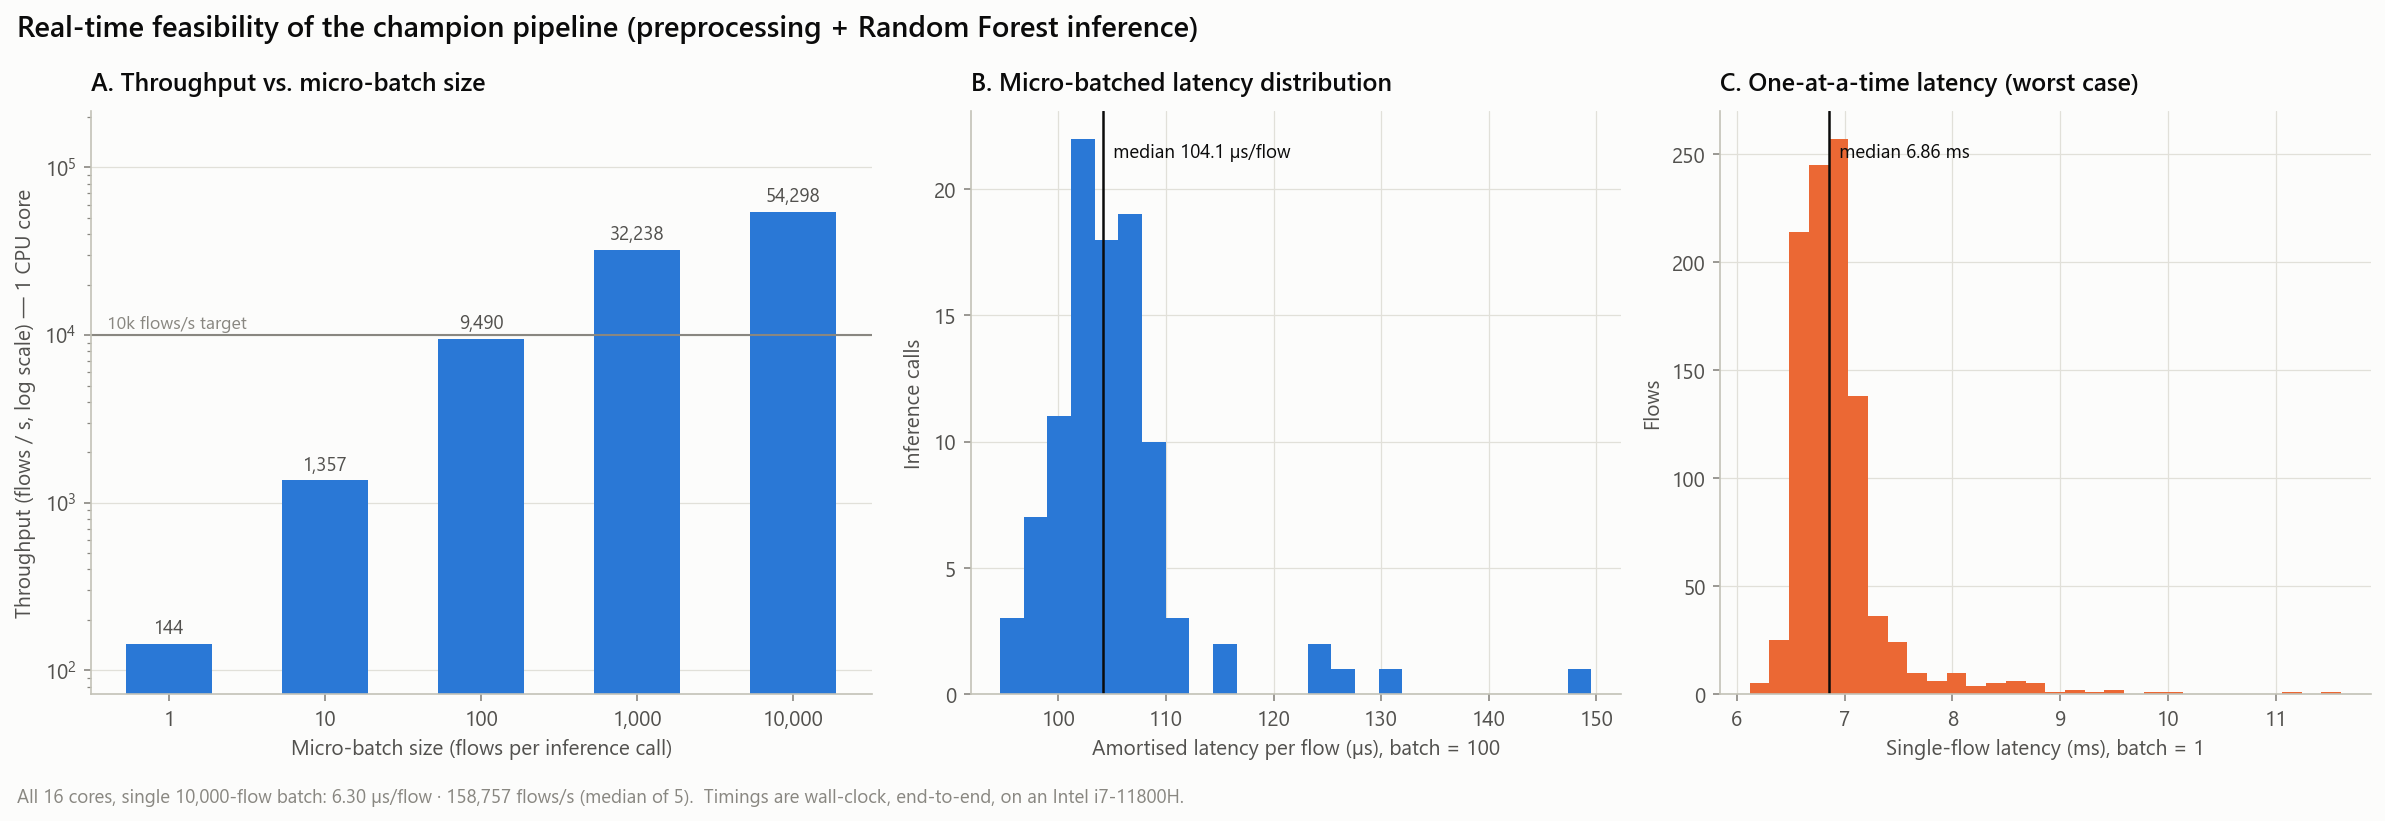

In [27]:
X_tr_raw, X_te_raw, cat_tr_raw, cat_te_raw = d["X_tr"], d["X_te"], d["cat_tr"], d["cat_te"]
tab, per_call, all_cores = benchmark(d["pre"], rf, X_te_raw.iloc[:N_BENCH])
display(tab.set_index("batch_size"))
print(f"all cores, one 10,000-flow batch: {all_cores['us_per_flow']:.2f} us/flow = {all_cores['flows_per_s']:,.0f} flows/s")
display(Image(filename=fig_latency(tab, per_call, all_cores), width=1000))

In [28]:
fam, fam_rep = train_family_classifier(d["pre"], X_tr_raw, cat_tr_raw, X_te_raw, cat_te_raw)
print("stage-2 family classifier:", {k: fam_rep[k] for k in ("accuracy", "macro_f1")})
lines = siem_stream(d["pre"], rf, fam, tau, X_te_raw, cat_te_raw)
print("\n".join(lines))

stage-2 family classifier: {'accuracy': 0.7531, 'macro_f1': 0.5676}


[2026-09-11 15:17:38.766] [ALERT] [HIGH] Malicious Flow #43134 Detected!  (wb-mon/-/INT)
  ├─ Attack Category : DoS   (stage-2 guess: match; ground truth: DoS)
  ├─ Detection       : TP
  ├─ Confidence Score: 100.00%   (τ* = 0.50)
  ├─ Latency         : 9,754.10 microseconds
  └─ Action Taken    : TCP RST Packet Dispatched | Flow Blocked
[2026-09-11 15:17:38.838] [ALERT] [HIGH] Malicious Flow #10923 Detected!  (narp/-/INT)
  ├─ Attack Category : Analysis   (stage-2 guess: MISMATCH; ground truth: Backdoor)
  ├─ Detection       : TP
  ├─ Confidence Score: 100.00%   (τ* = 0.50)
  ├─ Latency         : 8,962.40 microseconds
  └─ Action Taken    : TCP RST Packet Dispatched | Flow Blocked
[2026-09-11 15:17:38.901] [ALERT] [CRITICAL] Malicious Flow #50231 Detected!  (tcp/http/FIN)
  ├─ Attack Category : Exploits   (stage-2 guess: match; ground truth: Exploits)
  ├─ Detection       : TP
  ├─ Confidence Score: 99.99%   (τ* = 0.50)
  ├─ Latency         : 8,771.60 microseconds
  └─ Action Taken   

**Line-rate feasibility.** A 1 Gbps link at an average of ~1 KB per flow record produces on the order of
10⁴–10⁵ flows/s; flow exporters (NetFlow/IPFIX/Zeek) deliver records in batches, which is exactly the regime where the
pipeline runs at tens of microseconds per flow. One-flow-at-a-time scoring is far slower (milliseconds, dominated by
per-call Python overhead across all trees) — so production deployment should micro-batch, or compile the forest
(e.g. Treelite/ONNX) for the inline path.

## 13. Executive Recommendations for the CISO

1. **Deploy as an *augmenting* detection layer, not a replacement.** The model detects 94.6% of
   attacks at a 5.1% false-alarm rate; pair it with the existing signature NIDS so each covers the
   other's blind spots.
2. **Operate the threshold as policy.** τ* = 0.50 balances recall against a 5 % false-alarm
   budget; lowering τ during elevated threat levels buys recall at a measurable analyst cost (Section 8 curve).
3. **Micro-batch the inline path.** At 6.4 µs/flow batched (157,418 flows/s)
   the model sustains multi-gigabit flow export; avoid per-flow synchronous scoring.
4. **Close the Fuzzers gap.** Fuzzers alone drive the large majority of false negatives (Section 10); add
   payload/DPI features and service-crash telemetry for Fuzzers and Analysis.
5. **Continuous learning & drift monitoring.** Retrain on fresh, labelled SOC triage outcomes; monitor feature
   drift (new protocols map to all-zero one-hot vectors and silently weaken detection).

## Reproducibility & Consistency Check
The SOC dashboard, the command-line scripts and the report are all driven by the project's `src/` package and the
results it saved in `artifacts/`. This cell proves that the self-contained code above reproduces those saved results
**exactly** — so the notebook and the application cannot silently disagree.

In [29]:
ref = json.loads((ARTIFACT_DIR / "metrics_champion.json").read_text())
ref_recall = pd.read_csv(ARTIFACT_DIR / "attack_recall.csv").set_index("family").recall
checks = {"tau*": (tau, ref["threshold"]["tau_star"])}
for name, mine, saved in (("baseline", m_dt, ref["decision_tree"]), ("champion", m_rf, ref["random_forest_tau_star"])):
    for k in ("accuracy", "precision", "recall", "f1", "fpr", "roc_auc", "tp", "fp", "tn", "fn"):
        checks[f"{name}.{k}"] = (mine[k], saved[k])
for family, r in t.set_index("family").recall.items():
    checks[f"recall[{family}]"] = (round(float(r), 6), float(ref_recall[family]))
diverged = {k: v for k, v in checks.items() if abs(float(v[0]) - float(v[1])) > 1e-6}
assert not diverged, f"Notebook diverged from artifacts/: {diverged}"
print(f"Consistency check PASSED: all {len(checks)} values (τ*, baseline and champion metrics, confusion counts,")
print("9 per-family recalls) match the project's saved results exactly.")
print(f"Notebook executed end-to-end in {time.perf_counter() - T_START:.1f} s")

Consistency check PASSED: all 30 values (τ*, baseline and champion metrics, confusion counts,
9 per-family recalls) match the project's saved results exactly.
Notebook executed end-to-end in 62.5 s
